In [2]:
# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

import os
import glob
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from rasterio.warp import transform as rio_transform
from tqdm.auto import tqdm

In [3]:
import os
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
import numpy as np

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

# Input ecoregion shapefile
ecoregion_shp = "/mnt/eo/EO4Backcasting/_data/Ecoregions2017/Ecoregions2017.shp"

# Reference raster: output ecoregion raster will match this grid exactly
prob_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif"

# Output raster
out_dir = "/mnt/eo/EO4Backcasting/_data/ecoregions"
os.makedirs(out_dir, exist_ok=True)

ecoregion_raster_fp = os.path.join(
    out_dir,
    "ecoregions_boreal_temperate_mediterranean_aligned.tif"
)

# Name of the attribute column containing the ecoregion / biome names
# You may need to adapt this after inspecting the columns below.
ecoregion_name_col = "BIOME_NAME"

# Numeric codes for raster output
ecoregion_code_lookup = {
    "Boreal": 1,
    "Temperate": 2,
    "Mediterranean": 3
}

# ------------------------------------------------------------
# Load shapefile
# ------------------------------------------------------------

eco = gpd.read_file(ecoregion_shp)

print("Available columns:")
print(eco.columns.tolist())

print("\nCRS:")
print(eco.crs)

print("\nUnique original classes:")
print(eco[ecoregion_name_col].dropna().unique())

Available columns:
['OBJECTID', 'ECO_NAME', 'BIOME_NUM', 'BIOME_NAME', 'REALM', 'ECO_BIOME_', 'NNH', 'ECO_ID', 'SHAPE_LENG', 'SHAPE_AREA', 'NNH_NAME', 'COLOR', 'COLOR_BIO', 'COLOR_NNH', 'LICENSE', 'geometry']

CRS:
EPSG:4326

Unique original classes:
<ArrowStringArray>
[   'Mediterranean Forests, Woodlands & Scrub',
                   'Temperate Conifer Forests',
         'Temperate Broadleaf & Mixed Forests',
 'Temperate Grasslands, Savannas & Shrublands',
                                      'Tundra',
             'Montane Grasslands & Shrublands',
                        'Boreal Forests/Taiga']
Length: 7, dtype: str


In [ ]:
import os
import numpy as np
import rasterio
from rasterio.features import rasterize

# ------------------------------------------------------------
# Rasterize reclassified ecoregions to probability raster grid
# ------------------------------------------------------------

# Output raster
out_dir = "/mnt/eo/EO4Backcasting/_data/ecoregions"
os.makedirs(out_dir, exist_ok=True)

ecoregion_raster_fp = os.path.join(
    out_dir,
    "ecoregions_boreal_temperate_mediterranean_aligned.tif"
)

# Reference raster: output raster will match this grid exactly
prob_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif"

with rasterio.open(prob_fp) as ref:

    # Reproject polygons to probability raster CRS if necessary
    if eco_reclass.crs != ref.crs:
        eco_reclass = eco_reclass.to_crs(ref.crs)

    # Prepare polygon-value pairs for rasterization
    shapes = [
        (geom, int(code))
        for geom, code in zip(
            eco_reclass.geometry,
            eco_reclass["ecoregion_code"]
        )
        if geom is not None and not geom.is_empty
    ]

    # Rasterize to the exact grid of the probability raster
    ecoregion_arr = rasterize(
        shapes=shapes,
        out_shape=(ref.height, ref.width),
        transform=ref.transform,
        fill=0,               # 0 = NoData / outside selected classes
        dtype="uint8",
        all_touched=False     # False = conservative; True = include all touched pixels
    )

    # Copy reference raster profile and adapt it for the ecoregion raster
    profile = ref.profile.copy()
    profile.update(
        driver="GTiff",
        dtype="uint8",
        count=1,
        nodata=0,
        compress="deflate",
        tiled=True,
        blockxsize=512,
        blockysize=512,
        BIGTIFF="YES"
    )

    # Write raster
    with rasterio.open(ecoregion_raster_fp, "w", **profile) as dst:
        dst.write(ecoregion_arr, 1)
        dst.set_band_description(1, "ecoregion_simple")

print("Saved ecoregion raster:")
print(ecoregion_raster_fp)

# ------------------------------------------------------------
# Quick check
# ------------------------------------------------------------

with rasterio.open(ecoregion_raster_fp) as src:
    arr = src.read(1)

values, counts = np.unique(arr, return_counts=True)

print("\nPixel counts by class:")
for value, count in zip(values, counts):
    print(f"{value}: {count:,}")

print("\nClass lookup:")
print("0 = NoData / outside selected classes")
print("1 = Boreal")
print("2 = Temperate")
print("3 = Mediterranean")

Saved ecoregion raster:
/mnt/eo/EO4Backcasting/_data/ecoregions/ecoregions_boreal_temperate_mediterranean_aligned.tif


In [4]:
# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

# Output folder
out_dir = "/mnt/eo/EO4Backcasting/_analysis_samples"
os.makedirs(out_dir, exist_ok=True)

out_parquet = os.path.join(
    out_dir,
    "europe_probability_stratified_sample_with_genus_ecozone_STM1985.parquet"
)

out_csv = os.path.join(
    out_dir,
    "europe_probability_stratified_sample_with_genus_ecozone_STM1985.csv"
)

# Input rasters
prob_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif"
genus_fp = "/mnt/eo/EO4Backcasting/_data_aligned/genus_map_europe_aligned_to_probability_30m.tif"

# Optional ecozone raster
# Set use_ecozone_stratification = False if you do not have this yet
ecozone_fp = "/mnt/eo/EO4Backcasting/_data/ecoregions/ecoregions_boreal_temperate_mediterranean_aligned.tif"
use_ecozone_stratification = True

# STM root folder
stm_root = "/mnt/dss_europe/level3_repr/STM/"
stm_year = 1985

# STM bands / indices to extract
bands_to_extract = [
    "BLUE",
    "GREEN",
    "RED",
    "NIR",
    "SWIR1",
    "SWIR2",
    "NDVI",
    "NBR",
    "NDMI"
]

# STM metrics to extract from each multi-band STM file
# Start with Q50; later you can add "Q10", "Q90", "STD", "AVG", etc.
metrics_to_extract = "all"

# Raster scanning block size
block_size = 1024

# Random seed
seed = 42
rng = np.random.default_rng(seed)

# Probability classes
prob_class_lookup = {
    1: "very_low_0_025",
    2: "low_025_050",
    3: "moderate_050_075",
    4: "high_075_090",
    5: "very_high_090_100",
}

# Target number of samples per probability class
# High-probability classes are intentionally oversampled
target_per_prob_class = {
    "very_low_0_025":      50_000,
    "low_025_050":        50_000,
    "moderate_050_075":   75_000,
    "high_075_090":      125_000,
    "very_high_090_100": 200_000,
}

# Genus lookup
genus_lookup = {
    0: "Larix",
    1: "Picea",
    2: "Pinus",
    3: "Fagus",
    4: "Quercus",
    5: "Other needleleaf",
    6: "Other broadleaf",
    7: "No trees"
}

In [5]:
# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def classify_probability(prob_arr):
    """
    Convert probability values into integer probability classes.

    Class codes:
    1 = 0.00–0.25
    2 = >0.25–0.50
    3 = >0.50–0.75
    4 = >0.75–0.90
    5 = >0.90–1.00
    """
    cls = np.zeros(prob_arr.shape, dtype=np.uint8)

    cls[(prob_arr >= 0.00) & (prob_arr <= 0.25)] = 1
    cls[(prob_arr > 0.25) & (prob_arr <= 0.50)] = 2
    cls[(prob_arr > 0.50) & (prob_arr <= 0.75)] = 3
    cls[(prob_arr > 0.75) & (prob_arr <= 0.90)] = 4
    cls[(prob_arr > 0.90) & (prob_arr <= 1.00)] = 5

    return cls


def check_alignment(ref, other, name):
    """
    Check whether two rasters are aligned.
    """
    same = (
        ref.width == other.width and
        ref.height == other.height and
        ref.transform == other.transform and
        ref.crs == other.crs
    )

    print(f"{name} aligned with reference raster:", same)
    return same


def find_metric_band_indices(src, metrics="all"):
    """
    Find STM metric band indices from raster band descriptions.

    If metrics == "all", all bands are extracted using their band descriptions.
    Returns a dictionary: metric_name -> 1-based raster band index.
    """

    descriptions = src.descriptions

    metric_to_band = {}

    if metrics == "all":
        for idx in range(1, src.count + 1):
            desc = descriptions[idx - 1]

            if desc is None or str(desc).strip() == "":
                metric_name = f"B{idx}"
            else:
                metric_name = str(desc).strip()

            # Clean metric name for dataframe column names
            metric_name = (
                metric_name
                .replace(" ", "_")
                .replace("-", "_")
                .replace("/", "_")
                .replace(".", "_")
            )

            metric_to_band[metric_name] = idx

        return metric_to_band

    # Otherwise extract only selected metrics
    for metric in metrics:
        metric_lower = metric.lower()
        found = None

        for idx, desc in enumerate(descriptions, start=1):
            if desc is None:
                continue

            desc_clean = desc.lower().replace(" ", "").replace("-", "_")

            if metric_lower in desc_clean:
                found = idx
                break

        if found is None:
            raise ValueError(
                f"Could not find metric '{metric}' in band descriptions.\n"
                f"Available descriptions:\n{descriptions}"
            )

        metric_to_band[metric] = found

    return metric_to_band

In [6]:
# ------------------------------------------------------------
# Open rasters and check basic metadata
# ------------------------------------------------------------

prob_src = rasterio.open(prob_fp)
genus_src = rasterio.open(genus_fp)

if use_ecozone_stratification:
    ecozone_src = rasterio.open(ecozone_fp)
else:
    ecozone_src = None

print("Probability raster:")
print("Size:", prob_src.width, prob_src.height)
print("CRS:", prob_src.crs)
print("Transform:", prob_src.transform)

print("\nGenus raster:")
print("Size:", genus_src.width, genus_src.height)
print("CRS:", genus_src.crs)
print("Transform:", genus_src.transform)

check_alignment(prob_src, genus_src, "Genus")

if ecozone_src is not None:
    print("\nEcozone raster:")
    print("Size:", ecozone_src.width, ecozone_src.height)
    print("CRS:", ecozone_src.crs)
    print("Transform:", ecozone_src.transform)

    check_alignment(prob_src, ecozone_src, "Ecozone")

Probability raster:
Size: 130000 140000
CRS: EPSG:3035
Transform: | 30.00, 0.00, 2612197.93|
| 0.00,-30.00, 5565550.42|
| 0.00, 0.00, 1.00|

Genus raster:
Size: 130000 140000
CRS: EPSG:3035
Transform: | 30.00, 0.00, 2612197.93|
| 0.00,-30.00, 5565550.42|
| 0.00, 0.00, 1.00|
Genus aligned with reference raster: True

Ecozone raster:
Size: 130000 140000
CRS: EPSG:3035
Transform: | 30.00, 0.00, 2612197.93|
| 0.00,-30.00, 5565550.42|
| 0.00, 0.00, 1.00|
Ecozone aligned with reference raster: True


In [7]:
# ------------------------------------------------------------
# First pass: count available pixels per probability class × ecozone
# ------------------------------------------------------------

records = []

height = prob_src.height
width = prob_src.width

for row_off in tqdm(range(0, height, block_size), desc="Counting strata"):
    for col_off in range(0, width, block_size):

        win_h = min(block_size, height - row_off)
        win_w = min(block_size, width - col_off)
        window = Window(col_off, row_off, win_w, win_h)

        prob = prob_src.read(1, window=window, masked=True).filled(np.nan).astype("float32")
        genus = genus_src.read(1, window=window, masked=True).filled(-9999).astype("int16")

        valid = np.isfinite(prob) & (prob >= 0) & (prob <= 1)

        # Keep only valid genus classes and exclude "No trees"
        valid &= np.isin(genus, list(genus_lookup.keys()))
        valid &= genus != 7

        if ecozone_src is not None:
            ecozone = ecozone_src.read(1, window=window, masked=True).filled(-9999).astype("int32")
            valid &= ecozone != -9999
        else:
            # Single dummy ecozone if no ecozone stratification is used
            ecozone = np.ones(prob.shape, dtype="int32")

        if not np.any(valid):
            continue

        prob_class = classify_probability(prob)
        valid &= prob_class > 0

        if not np.any(valid):
            continue

        tmp = pd.DataFrame({
            "prob_class_code": prob_class[valid],
            "ecozone_code": ecozone[valid]
        })

        counts = (
            tmp
            .groupby(["prob_class_code", "ecozone_code"])
            .size()
            .reset_index(name="n_available")
        )

        records.append(counts)

stratum_counts = (
    pd.concat(records, ignore_index=True)
    .groupby(["prob_class_code", "ecozone_code"], as_index=False)["n_available"]
    .sum()
)

stratum_counts["prob_class"] = stratum_counts["prob_class_code"].map(prob_class_lookup)

display(stratum_counts.head())
display(
    stratum_counts
    .groupby("prob_class", as_index=False)["n_available"]
    .sum()
)

Counting strata:   0%|          | 0/137 [00:00<?, ?it/s]

,prob_class_code,ecozone_code,n_available,prob_class
0,1,1,28100567,very_low_0_025
1,1,2,48552139,very_low_0_025
2,1,3,6520706,very_low_0_025
3,1,241,483942,very_low_0_025
4,2,1,148347300,low_025_050


,prob_class,n_available
0,high_075_090,126987990
1,low_025_050,535691374
2,moderate_050_075,669384344
3,very_high_090_100,14576728
4,very_low_0_025,83657354


In [8]:
# ------------------------------------------------------------
# Define target sample size per probability class × ecozone
# ------------------------------------------------------------

targets = []

for prob_code, prob_label in prob_class_lookup.items():

    df_c = stratum_counts[stratum_counts["prob_class_code"] == prob_code].copy()

    if df_c.empty:
        continue

    target_total = target_per_prob_class[prob_label]

    # Distribute target samples equally across ecozones within each probability class.
    # If ecozone is not used, there is only one dummy ecozone.
    n_strata = len(df_c)
    base_target = int(np.ceil(target_total / n_strata))

    df_c["n_target_raw"] = base_target
    df_c["n_target"] = np.minimum(df_c["n_target_raw"], df_c["n_available"])

    targets.append(df_c)

sample_targets = pd.concat(targets, ignore_index=True)

print("Total target samples:", sample_targets["n_target"].sum())

display(
    sample_targets
    .groupby("prob_class", as_index=False)
    .agg(
        n_available=("n_available", "sum"),
        n_target=("n_target", "sum")
    )
)

Total target samples: 500000


,prob_class,n_available,n_target
0,high_075_090,126987990,125000
1,low_025_050,535691374,50000
2,moderate_050_075,669384344,75000
3,very_high_090_100,14576728,200000
4,very_low_0_025,83657354,50000


In [9]:
# ------------------------------------------------------------
# Second pass: reservoir sampling per stratum
# ------------------------------------------------------------

target_dict = {
    (int(row.prob_class_code), int(row.ecozone_code)): int(row.n_target)
    for _, row in sample_targets.iterrows()
}

sample_store = {
    key: {
        "rows": [],
        "cols": [],
        "probability": [],
        "genus_code": [],
        "ecozone_code": []
    }
    for key in target_dict.keys()
}

seen_count = {key: 0 for key in target_dict.keys()}

for row_off in tqdm(range(0, height, block_size), desc="Sampling pixels"):
    for col_off in range(0, width, block_size):

        win_h = min(block_size, height - row_off)
        win_w = min(block_size, width - col_off)
        window = Window(col_off, row_off, win_w, win_h)

        prob = prob_src.read(1, window=window, masked=True).filled(np.nan).astype("float32")
        genus = genus_src.read(1, window=window, masked=True).filled(-9999).astype("int16")

        valid = np.isfinite(prob) & (prob >= 0) & (prob <= 1)
        valid &= np.isin(genus, list(genus_lookup.keys()))
        valid &= genus != 7

        if ecozone_src is not None:
            ecozone = ecozone_src.read(1, window=window, masked=True).filled(-9999).astype("int32")
            valid &= ecozone != -9999
        else:
            ecozone = np.ones(prob.shape, dtype="int32")

        if not np.any(valid):
            continue

        prob_class = classify_probability(prob)
        valid &= prob_class > 0

        if not np.any(valid):
            continue

        # Process each present stratum in this block
        present_pairs = np.unique(
            np.stack([prob_class[valid], ecozone[valid]], axis=1),
            axis=0
        )

        for pc, ez in present_pairs:

            key = (int(pc), int(ez))

            if key not in target_dict:
                continue

            target_n = target_dict[key]

            if target_n <= 0:
                continue

            mask = valid & (prob_class == pc) & (ecozone == ez)
            r_loc, c_loc = np.where(mask)

            if len(r_loc) == 0:
                continue

            r_global = r_loc + row_off
            c_global = c_loc + col_off

            vals_prob = prob[r_loc, c_loc]
            vals_genus = genus[r_loc, c_loc]
            vals_ecozone = ecozone[r_loc, c_loc]

            store = sample_store[key]

            for j in range(len(r_global)):

                seen_count[key] += 1
                n_seen = seen_count[key]

                if len(store["rows"]) < target_n:
                    store["rows"].append(int(r_global[j]))
                    store["cols"].append(int(c_global[j]))
                    store["probability"].append(float(vals_prob[j]))
                    store["genus_code"].append(int(vals_genus[j]))
                    store["ecozone_code"].append(int(vals_ecozone[j]))

                else:
                    # Reservoir replacement
                    k = rng.integers(0, n_seen)

                    if k < target_n:
                        store["rows"][k] = int(r_global[j])
                        store["cols"][k] = int(c_global[j])
                        store["probability"][k] = float(vals_prob[j])
                        store["genus_code"][k] = int(vals_genus[j])
                        store["ecozone_code"][k] = int(vals_ecozone[j])

Sampling pixels:   0%|          | 0/137 [00:00<?, ?it/s]

In [10]:
# ------------------------------------------------------------
# Convert sampled pixels to dataframe
# ------------------------------------------------------------

dfs = []

for key, store in sample_store.items():

    pc, ez = key

    if len(store["rows"]) == 0:
        continue

    tmp = pd.DataFrame(store)
    tmp["prob_class_code"] = pc
    tmp["prob_class"] = prob_class_lookup[pc]
    dfs.append(tmp)

sample_df = pd.concat(dfs, ignore_index=True)

# Add spatial coordinates in probability raster CRS
xs, ys = rasterio.transform.xy(
    prob_src.transform,
    sample_df["rows"].values,
    sample_df["cols"].values,
    offset="center"
)

sample_df["x"] = xs
sample_df["y"] = ys

# Add genus names
sample_df["genus"] = sample_df["genus_code"].map(genus_lookup)

# Add sample weights for representative summaries later
sampled_counts = (
    sample_df
    .groupby(["prob_class_code", "ecozone_code"])
    .size()
    .reset_index(name="n_sampled")
)

weights = sample_targets.merge(
    sampled_counts,
    on=["prob_class_code", "ecozone_code"],
    how="left"
)

weights["n_sampled"] = weights["n_sampled"].fillna(0)
weights["sample_weight"] = weights["n_available"] / weights["n_sampled"]

sample_df = sample_df.merge(
    weights[["prob_class_code", "ecozone_code", "sample_weight"]],
    on=["prob_class_code", "ecozone_code"],
    how="left"
)

print("Total samples:", len(sample_df))
display(sample_df.head())

display(
    sample_df
    .groupby("prob_class")
    .size()
    .reset_index(name="n_samples")
)

display(
    sample_df
    .groupby(["prob_class", "genus"])
    .size()
    .reset_index(name="n_samples")
    .sort_values(["prob_class", "n_samples"], ascending=[True, False])
)

Total samples: 500000


,rows,cols,probability,genus_code,ecozone_code,prob_class_code,prob_class,x,y,genus,sample_weight
0,25121,68055,0.130788,6,1,1,very_low_0_025,4.653863e+06,4.811905e+06,Other broadleaf,2248.04536
1,49708,61218,0.084824,1,1,1,very_low_0_025,4.448753e+06,4.074295e+06,Picea,2248.04536
2,49395,63583,0.140289,1,1,1,very_low_0_025,4.519703e+06,4.083685e+06,Picea,2248.04536
3,36266,85376,0.191974,1,1,1,very_low_0_025,5.173493e+06,4.477555e+06,Picea,2248.04536
4,35419,88376,0.184383,1,1,1,very_low_0_025,5.263493e+06,4.502965e+06,Picea,2248.04536


,prob_class,n_samples
0,high_075_090,125000
1,low_025_050,50000
2,moderate_050_075,75000
3,very_high_090_100,200000
4,very_low_0_025,50000


,prob_class,genus,n_samples
5,high_075_090,Pinus,44277
4,high_075_090,Picea,40750
2,high_075_090,Other broadleaf,21932
6,high_075_090,Quercus,12680
0,high_075_090,Fagus,2726
3,high_075_090,Other needleleaf,2416
1,high_075_090,Larix,219
9,low_025_050,Other broadleaf,14869
12,low_025_050,Pinus,14629
11,low_025_050,Picea,7896


In [11]:
# ------------------------------------------------------------
# Inspect STM files and band descriptions
# ------------------------------------------------------------

example_files = glob.glob(
    os.path.join(
        stm_root,
        "X*_Y*",
        f"{stm_year}0101-{stm_year}1231*_HL_TSA_LNDLG_*_STM.tif"
    )
)

print("Number of STM files found:", len(example_files))

if len(example_files) == 0:
    raise FileNotFoundError(
        "No STM files found. Check stm_root, stm_year, and filename pattern."
    )

example_fp = example_files[0]
print("Example STM file:")
print(example_fp)

with rasterio.open(example_fp) as src:
    print("CRS:", src.crs)
    print("Size:", src.width, src.height)
    print("Number of bands:", src.count)
    print("Descriptions:")
    for i, desc in enumerate(src.descriptions, start=1):
        print(i, desc)

    # Test metric detection
    metric_band_indices = find_metric_band_indices(src, metrics_to_extract)
    print("Detected metric bands:", metric_band_indices)

Number of STM files found: 4389
Example STM file:
/mnt/dss_europe/level3_repr/STM/X0002_Y0023/19850101-19851231_001-365_HL_TSA_LNDLG_NDVI_STM.tif
CRS: EPSG:3035
Size: 5000 5000
Number of bands: 7
Descriptions:
1 Q10
2 Q25
3 Q50
4 Q75
5 Q90
6 AVG
7 STD
Detected metric bands: {'Q10': 1, 'Q25': 2, 'Q50': 3, 'Q75': 4, 'Q90': 5, 'AVG': 6, 'STD': 7}


In [12]:
# ------------------------------------------------------------
# Build STM file index: tile × band
# ------------------------------------------------------------

stm_records = []

for tile_dir in sorted(glob.glob(os.path.join(stm_root, "X*_Y*"))):

    tile_id = os.path.basename(tile_dir)

    for band in bands_to_extract:

        pattern = os.path.join(
            tile_dir,
            f"{stm_year}0101-{stm_year}1231*_HL_TSA_LNDLG_{band}_STM.tif"
        )

        matches = glob.glob(pattern)

        if len(matches) == 0:
            continue

        if len(matches) > 1:
            print(f"Warning: multiple files found for {tile_id}, {band}. Using first one.")

        stm_records.append({
            "tile_id": tile_id,
            "band": band,
            "path": matches[0]
        })

stm_index = pd.DataFrame(stm_records)

print("Indexed STM files:", len(stm_index))
display(stm_index.head())
display(stm_index["band"].value_counts())

Indexed STM files: 3591


,tile_id,band,path
0,X0001_Y0024,BLUE,/mnt/dss_europe/level3_repr/STM/X0001_Y0024/19...
1,X0001_Y0024,GREEN,/mnt/dss_europe/level3_repr/STM/X0001_Y0024/19...
2,X0001_Y0024,RED,/mnt/dss_europe/level3_repr/STM/X0001_Y0024/19...
3,X0001_Y0024,NIR,/mnt/dss_europe/level3_repr/STM/X0001_Y0024/19...
4,X0001_Y0024,SWIR1,/mnt/dss_europe/level3_repr/STM/X0001_Y0024/19...


band
BLUE     399
GREEN    399
RED      399
NIR      399
SWIR1    399
SWIR2    399
NDVI     399
NBR      399
NDMI     399
Name: count, dtype: int64

In [19]:
import os
import psutil

# ------------------------------------------------------------
# Balanced CPU settings for shared server use
# ------------------------------------------------------------

p = psutil.Process(os.getpid())

# Use 24 out of 48 logical CPUs
# This leaves 24 logical CPUs free for other users/processes.
cpus_to_use = list(range(24))
p.cpu_affinity(cpus_to_use)

# Lower priority slightly, so other users/processes get preference if needed
p.nice(10)

# Keep internal library threading moderate.
# The STM extraction loop itself is mostly serial, so very high thread counts
# usually do not help much and can create unnecessary load.
os.environ["GDAL_NUM_THREADS"] = "4"
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"] = "4"

print("Logical CPUs on system:", psutil.cpu_count(logical=True))
print("Current process affinity:", p.cpu_affinity())
print("Number of CPUs available to this process:", len(p.cpu_affinity()))
print("Current nice level:", p.nice())
print("Total system CPU usage:", psutil.cpu_percent(interval=2), "%")

Logical CPUs on system: 48
Current process affinity: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Number of CPUs available to this process: 24
Current nice level: 10
Total system CPU usage: 2.3 %


In [21]:
# ------------------------------------------------------------
# Detect available STM metrics from one example STM file
# ------------------------------------------------------------

example_files = glob.glob(
    os.path.join(
        stm_root,
        "X*_Y*",
        f"{stm_year}0101-{stm_year}1231*_HL_TSA_LNDLG_*_STM.tif"
    )
)

print("Number of STM files found:", len(example_files))

if len(example_files) == 0:
    raise FileNotFoundError(
        "No STM files found. Check stm_root, stm_year, and filename pattern."
    )

example_fp = example_files[0]

print("Example STM file:")
print(example_fp)

with rasterio.open(example_fp) as src:
    print("CRS:", src.crs)
    print("Size:", src.width, src.height)
    print("Number of bands:", src.count)
    print("Band descriptions:")

    for i, desc in enumerate(src.descriptions, start=1):
        print(i, desc)

    metric_band_indices_example = find_metric_band_indices(
        src,
        metrics=metrics_to_extract
    )

available_metrics = list(metric_band_indices_example.keys())

print("\nAvailable STM metrics detected:")
print(available_metrics)

Number of STM files found: 4389
Example STM file:
/mnt/dss_europe/level3_repr/STM/X0002_Y0023/19850101-19851231_001-365_HL_TSA_LNDLG_NDVI_STM.tif
CRS: EPSG:3035
Size: 5000 5000
Number of bands: 7
Band descriptions:
1 Q10
2 Q25
3 Q50
4 Q75
5 Q90
6 AVG
7 STD

Available STM metrics detected:
['Q10', 'Q25', 'Q50', 'Q75', 'Q90', 'AVG', 'STD']


In [22]:
# ------------------------------------------------------------
# Extract STM values from tiled STM rasters
# ------------------------------------------------------------

# Use detected metrics if all STM bands are extracted
metrics_for_columns = available_metrics if metrics_to_extract == "all" else metrics_to_extract

df_analysis = sample_df.copy()

# Create empty output columns
for band in bands_to_extract:
    for metric in metrics_for_columns:
        df_analysis[f"{band}_{metric}"] = np.nan

# Sample coordinates
xs = df_analysis["x"].to_numpy()
ys = df_analysis["y"].to_numpy()

sample_crs = prob_src.crs
n_total = len(df_analysis)

for _, row in tqdm(
    stm_index.iterrows(),
    total=len(stm_index),
    desc="Extracting STM values"
):

    band = row["band"]
    fp = row["path"]

    # Limit GDAL-internal threading during raster access.
    # This keeps the extraction reasonably fast without letting GDAL use too many threads per file.
    with rasterio.Env(GDAL_NUM_THREADS="4"):
        with rasterio.open(fp) as src:

            metric_band_indices = find_metric_band_indices(src, metrics_to_extract)

            # Reproject sample coordinates if necessary
            if src.crs != sample_crs:
                xs_src, ys_src = rio_transform(
                    sample_crs,
                    src.crs,
                    xs.tolist(),
                    ys.tolist()
                )

                xs_src = np.array(xs_src)
                ys_src = np.array(ys_src)

            else:
                xs_src = xs
                ys_src = ys

            # Select sample points inside this STM tile
            b = src.bounds

            inside = (
                (xs_src >= b.left) &
                (xs_src <= b.right) &
                (ys_src >= b.bottom) &
                (ys_src <= b.top)
            )

            idx_inside = np.where(inside)[0]

            if len(idx_inside) == 0:
                continue

            coords = list(zip(xs_src[idx_inside], ys_src[idx_inside]))
            nodata = src.nodata

            for metric, band_index in metric_band_indices.items():

                values = []

                for val in src.sample(coords, indexes=band_index):
                    v = val[0]

                    if nodata is not None and v == nodata:
                        values.append(np.nan)
                    else:
                        values.append(v)

                out_col = f"{band}_{metric}"
                df_analysis.loc[idx_inside, out_col] = values

# ------------------------------------------------------------
# Create STM column list
# ------------------------------------------------------------

stm_cols = [
    f"{band}_{metric}"
    for band in bands_to_extract
    for metric in metrics_for_columns
]

# ------------------------------------------------------------
# Clean obvious no-data / invalid STM values
# ------------------------------------------------------------

for col in stm_cols:
    df_analysis.loc[df_analysis[col] < -9000, col] = np.nan

df_analysis["n_valid_stm"] = df_analysis[stm_cols].notna().sum(axis=1)

# ------------------------------------------------------------
# Check extraction success
# ------------------------------------------------------------

print("STM extraction summary:")
for col in stm_cols:
    n_valid = df_analysis[col].notna().sum()
    print(f"{col}: {n_valid:,} / {n_total:,} valid values")

print("\nSamples with at least one valid STM value:")
print((df_analysis["n_valid_stm"] > 0).sum(), "/", len(df_analysis))

Extracting STM values:   0%|          | 0/3591 [00:00<?, ?it/s]

STM extraction summary:
BLUE_Q10: 480,999 / 500,000 valid values
BLUE_Q25: 480,999 / 500,000 valid values
BLUE_Q50: 480,999 / 500,000 valid values
BLUE_Q75: 480,999 / 500,000 valid values
BLUE_Q90: 480,999 / 500,000 valid values
BLUE_AVG: 480,999 / 500,000 valid values
BLUE_STD: 480,999 / 500,000 valid values
GREEN_Q10: 480,999 / 500,000 valid values
GREEN_Q25: 480,999 / 500,000 valid values
GREEN_Q50: 480,999 / 500,000 valid values
GREEN_Q75: 480,999 / 500,000 valid values
GREEN_Q90: 480,999 / 500,000 valid values
GREEN_AVG: 480,999 / 500,000 valid values
GREEN_STD: 480,999 / 500,000 valid values
RED_Q10: 480,999 / 500,000 valid values
RED_Q25: 480,999 / 500,000 valid values
RED_Q50: 480,999 / 500,000 valid values
RED_Q75: 480,999 / 500,000 valid values
RED_Q90: 480,999 / 500,000 valid values
RED_AVG: 480,999 / 500,000 valid values
RED_STD: 480,999 / 500,000 valid values
NIR_Q10: 480,999 / 500,000 valid values
NIR_Q25: 480,999 / 500,000 valid values
NIR_Q50: 480,999 / 500,000 valid va

In [23]:
# ------------------------------------------------------------
# Optional: clean obvious no-data / invalid STM values
# ------------------------------------------------------------

# Adapt if your STM nodata values are different.
# FORCE outputs can sometimes contain extreme nodata values.
for col in stm_cols:
    df_analysis.loc[df_analysis[col] < -9000, col] = np.nan

# Optional: drop samples without any STM information
df_analysis["n_valid_stm"] = df_analysis[stm_cols].notna().sum(axis=1)

print("Samples with at least one valid STM value:")
print((df_analysis["n_valid_stm"] > 0).sum(), "/", len(df_analysis))

# If desired:
# df_analysis = df_analysis[df_analysis["n_valid_stm"] > 0].copy()

Samples with at least one valid STM value:
480999 / 500000


In [24]:
# ------------------------------------------------------------
# Save analysis-ready dataframe
# ------------------------------------------------------------

df_analysis.to_parquet(out_parquet, index=False)
df_analysis.to_csv(out_csv, index=False)

print("Saved:")
print(out_parquet)
print(out_csv)

print("Rows:", len(df_analysis))
print("Columns:", len(df_analysis.columns))

Saved:
/mnt/eo/EO4Backcasting/_analysis_samples/europe_probability_stratified_sample_with_genus_ecozone_STM1985.parquet
/mnt/eo/EO4Backcasting/_analysis_samples/europe_probability_stratified_sample_with_genus_ecozone_STM1985.csv
Rows: 500000
Columns: 75


In [25]:
# ------------------------------------------------------------
# Quick checks
# ------------------------------------------------------------

display(df_analysis.head())

display(
    df_analysis
    .groupby("prob_class")
    .size()
    .reset_index(name="n_samples")
)

display(
    df_analysis
    .groupby(["prob_class", "genus"])
    .size()
    .reset_index(name="n_samples")
    .sort_values(["prob_class", "n_samples"], ascending=[True, False])
)

display(
    df_analysis[stm_cols].describe().T
)

,rows,cols,probability,genus_code,ecozone_code,prob_class_code,prob_class,x,y,genus,...,NBR_AVG,NBR_STD,NDMI_Q10,NDMI_Q25,NDMI_Q50,NDMI_Q75,NDMI_Q90,NDMI_AVG,NDMI_STD,n_valid_stm
0,25121,68055,0.130788,6,1,1,very_low_0_025,4.653863e+06,4.811905e+06,Other broadleaf,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,49708,61218,0.084824,1,1,1,very_low_0_025,4.448753e+06,4.074295e+06,Picea,...,4271.0,2225.0,-591.0,-14.0,960.0,1878.0,2355.0,904.0,1583.0,63
2,49395,63583,0.140289,1,1,1,very_low_0_025,4.519703e+06,4.083685e+06,Picea,...,4249.0,2558.0,-609.0,238.0,900.0,1752.0,2941.0,1090.0,2021.0,63
3,36266,85376,0.191974,1,1,1,very_low_0_025,5.173493e+06,4.477555e+06,Picea,...,4526.0,2116.0,-687.0,-423.0,1608.0,2931.0,2994.0,1305.0,1859.0,63
4,35419,88376,0.184383,1,1,1,very_low_0_025,5.263493e+06,4.502965e+06,Picea,...,4288.0,293.0,683.0,731.0,1127.0,1209.0,1381.0,1043.0,350.0,63


,prob_class,n_samples
0,high_075_090,125000
1,low_025_050,50000
2,moderate_050_075,75000
3,very_high_090_100,200000
4,very_low_0_025,50000


,prob_class,genus,n_samples
5,high_075_090,Pinus,44277
4,high_075_090,Picea,40750
2,high_075_090,Other broadleaf,21932
6,high_075_090,Quercus,12680
0,high_075_090,Fagus,2726
3,high_075_090,Other needleleaf,2416
1,high_075_090,Larix,219
9,low_025_050,Other broadleaf,14869
12,low_025_050,Pinus,14629
11,low_025_050,Picea,7896


,count,mean,std,min,25%,50%,75%,max
BLUE_Q10,480999.0,271.998511,130.296346,-260.0,181.0,239.0,340.0,3448.0
BLUE_Q25,480999.0,300.099742,136.080326,-67.0,202.0,265.0,374.0,3448.0
BLUE_Q50,480999.0,343.750918,150.586815,-67.0,232.0,309.0,429.0,3448.0
BLUE_Q75,480999.0,401.203163,173.216692,-67.0,272.0,368.0,500.0,4711.0
BLUE_Q90,480999.0,453.072921,205.638042,-67.0,302.0,417.0,568.0,5537.0
...,...,...,...,...,...,...,...,...
NDMI_Q50,480995.0,2544.114043,1623.142741,-5117.0,1497.0,2987.0,3756.0,9875.0
NDMI_Q75,480995.0,2901.374601,1511.739444,-5117.0,1993.0,3318.0,3992.0,9875.0
NDMI_Q90,480995.0,3135.839364,1455.087307,-5117.0,2316.0,3511.0,4155.0,9875.0
NDMI_AVG,480995.0,2492.123324,1542.070877,-5117.0,1459.0,2853.0,3640.0,9875.0


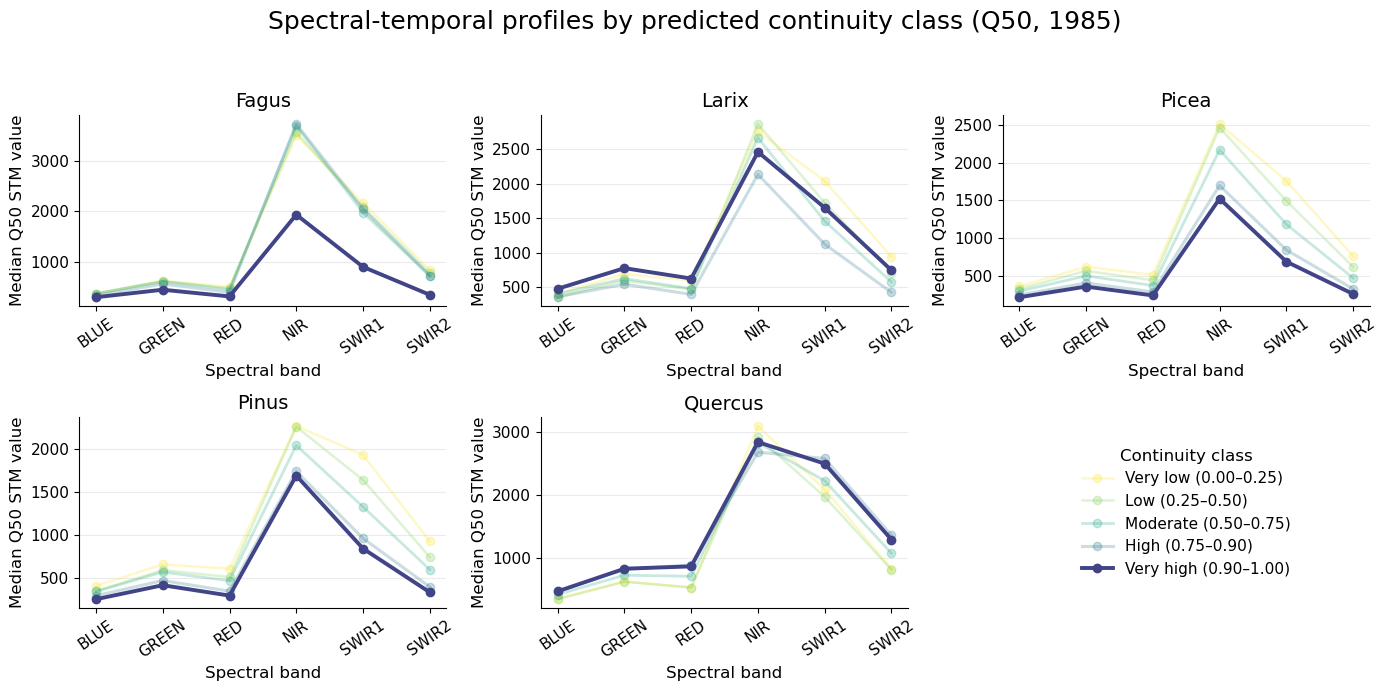

/mnt/eo/EO4Backcasting/_analysis_samples/spectral_profile_by_genus_continuity_classes_Q50_1985_custom_transparency.png


In [33]:
# ------------------------------------------------------------
# Spectral profile plot: Q50 by continuity class and genus
# continuous-like color scheme + stronger transparency
# ------------------------------------------------------------

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

bands_plot = ["BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2"]
metric_plot = "Q50"

stm_cols_plot = [f"{band}_{metric_plot}" for band in bands_plot]

# Check whether required STM columns exist
missing = [col for col in stm_cols_plot if col not in df_analysis.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Genera to show
genera_order = ["Fagus", "Larix", "Picea", "Pinus", "Quercus"]

# Probability class order
prob_order = [
    "very_low_0_025",
    "low_025_050",
    "moderate_050_075",
    "high_075_090",
    "very_high_090_100"
]

# Continuous-like color scheme: yellow -> green -> teal -> blue-green -> dark blue/violet
base_colors = {
    "very_low_0_025":    "#FDE725",
    "low_025_050":       "#7AD151",
    "moderate_050_075":  "#22A884",
    "high_075_090":      "#2A788E",
    "very_high_090_100": "#414487",
}

# Stronger transparency for lower probability classes
alpha_map = {
    "very_low_0_025": 0.25,
    "low_025_050": 0.25,
    "moderate_050_075": 0.25,
    "high_075_090": 0.25,
    "very_high_090_100": 1.00
}

# Convert colors to RGBA, so transparency is applied reliably
plot_colors = {
    k: to_rgba(base_colors[k], alpha=alpha_map[k])
    for k in prob_order
}

# Emphasise very high probabilities slightly
linewidth_map = {
    "very_low_0_025": 1.8,
    "low_025_050": 1.8,
    "moderate_050_075": 2.0,
    "high_075_090": 2.2,
    "very_high_090_100": 2.8
}

legend_labels = {
    "very_low_0_025": "Very low (0.00–0.25)",
    "low_025_050": "Low (0.25–0.50)",
    "moderate_050_075": "Moderate (0.50–0.75)",
    "high_075_090": "High (0.75–0.90)",
    "very_high_090_100": "Very high (0.90–1.00)"
}

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

df_plot = df_analysis.copy()

# Keep only selected genera
df_plot = df_plot[df_plot["genus"].isin(genera_order)].copy()

# Convert to long format
df_long = df_plot.melt(
    id_vars=["genus", "prob_class", "probability"],
    value_vars=stm_cols_plot,
    var_name="band_metric",
    value_name="stm_value"
)

# Extract band name
df_long["band"] = (
    df_long["band_metric"]
    .str.replace(f"_{metric_plot}", "", regex=False)
)

df_long["band"] = pd.Categorical(
    df_long["band"],
    categories=bands_plot,
    ordered=True
)

df_long["prob_class"] = pd.Categorical(
    df_long["prob_class"],
    categories=prob_order,
    ordered=True
)

df_long["genus"] = pd.Categorical(
    df_long["genus"],
    categories=genera_order,
    ordered=True
)

# Remove invalid values
df_long = df_long.replace([np.inf, -np.inf], np.nan)
df_long = df_long[df_long["stm_value"].notna()].copy()

# Median STM values per genus × probability class × band
df_summary = (
    df_long
    .groupby(["genus", "prob_class", "band"], observed=True)["stm_value"]
    .median()
    .reset_index()
)

# ------------------------------------------------------------
# Create multi-panel figure
# ------------------------------------------------------------

n_panels = len(genera_order)
ncols = 3
nrows = math.ceil((n_panels + 1) / ncols)  # +1 for legend panel

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 7),
    squeeze=False
)

axes_flat = axes.flatten()

# ------------------------------------------------------------
# Plot one genus per panel
# ------------------------------------------------------------

for i, genus in enumerate(genera_order):
    ax = axes_flat[i]

    sub = df_summary[df_summary["genus"] == genus].copy()

    # Plot lower probability classes first, very high last
    for prob_class in prob_order:
        sub_pc = sub[sub["prob_class"] == prob_class].copy()

        if sub_pc.empty:
            continue

        sub_pc = sub_pc.sort_values("band")

        ax.plot(
            sub_pc["band"],
            sub_pc["stm_value"],
            color=plot_colors[prob_class],
            linewidth=linewidth_map[prob_class],
            marker="o",
            markersize=6,
            markerfacecolor=plot_colors[prob_class],
            markeredgecolor=plot_colors[prob_class],
            zorder=10 if prob_class == "very_high_090_100" else 5
        )

    ax.set_title(genus, fontsize=14)
    ax.set_xlabel("Spectral band", fontsize=12)
    ax.set_ylabel(f"Median {metric_plot} STM value", fontsize=12)

    ax.tick_params(axis="x", rotation=35, labelsize=11)
    ax.tick_params(axis="y", labelsize=11)

    ax.grid(True, axis="y", alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Legend in empty panel below Picea
# ------------------------------------------------------------

legend_ax = axes_flat[n_panels]
legend_ax.axis("off")

legend_handles = [
    Line2D(
        [0], [0],
        color=plot_colors[k],
        marker="o",
        markerfacecolor=plot_colors[k],
        markeredgecolor=plot_colors[k],
        linewidth=linewidth_map[k],
        label=legend_labels[k]
    )
    for k in prob_order
]

legend_ax.legend(
    handles=legend_handles,
    title="Continuity class",
    loc="center",
    frameon=False,
    fontsize=11,
    title_fontsize=12,
    ncol=1
)

# Hide any remaining empty axes
for j in range(n_panels + 1, len(axes_flat)):
    axes_flat[j].axis("off")

# ------------------------------------------------------------
# Title and layout
# ------------------------------------------------------------

fig.suptitle(
    f"Spectral-temporal profiles by predicted continuity class ({metric_plot}, {stm_year})",
    fontsize=18,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

out_plot_fp = os.path.join(
    out_dir,
    f"spectral_profile_by_genus_continuity_classes_{metric_plot}_{stm_year}_custom_transparency.png"
)

plt.savefig(out_plot_fp, dpi=300, bbox_inches="tight")
plt.show()

print(out_plot_fp)

Genera shown in this order:
['Picea', 'Pinus', 'Larix', 'Fagus', 'Quercus', 'Other needleleaf', 'Other broadleaf']
Shared y-axis limits:
(-160.7, 4837.45)


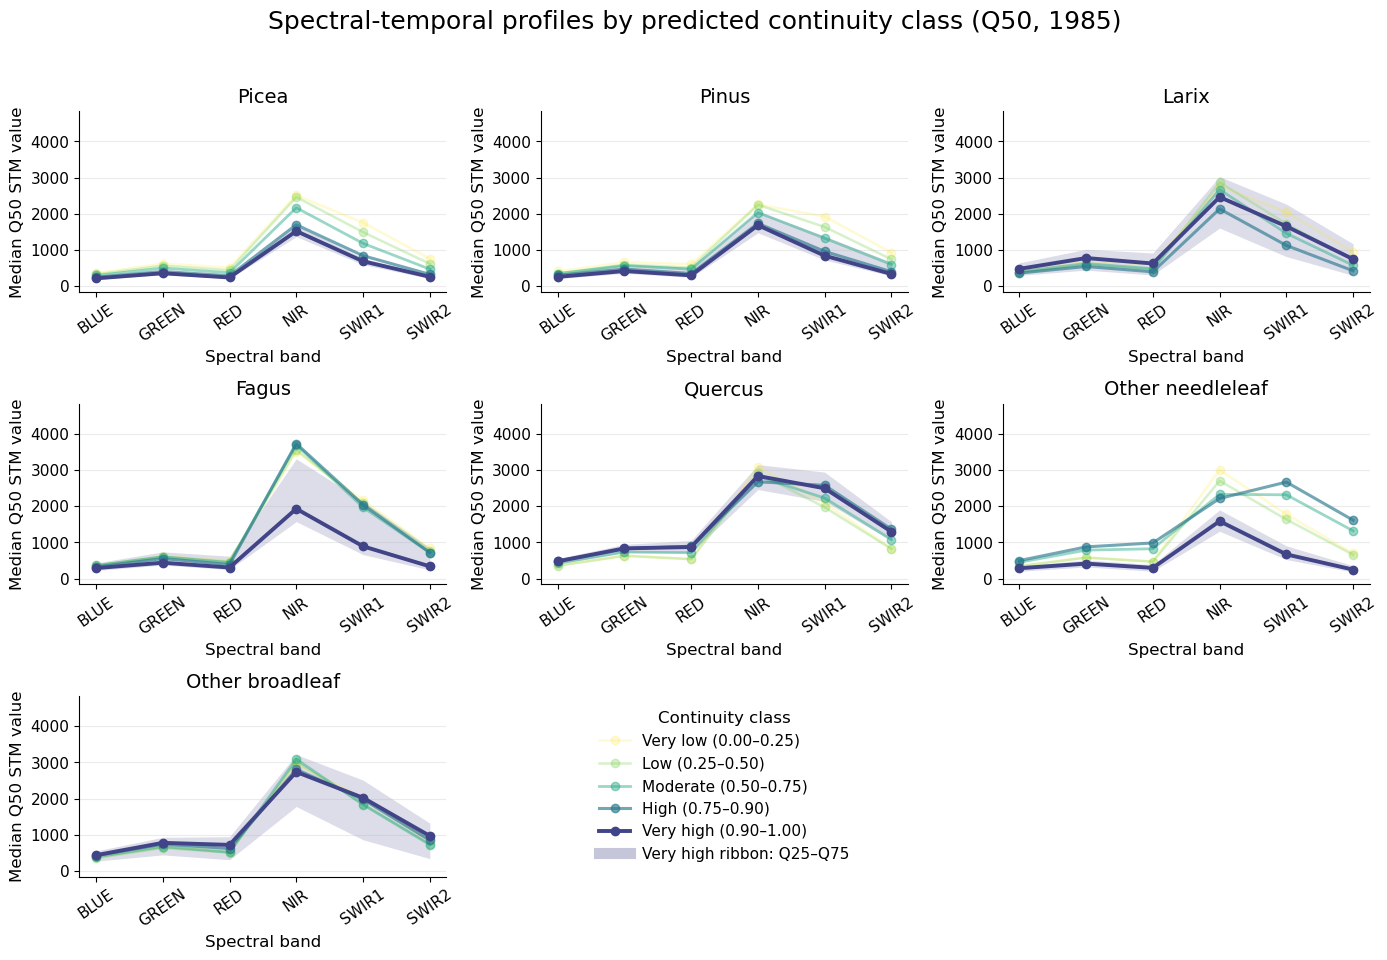

/mnt/eo/EO4Backcasting/_analysis_samples/spectral_profile_manual_genus_order_continuity_classes_Q50_1985_shared_yaxis.png


In [55]:
# ------------------------------------------------------------
# Spectral profile plot: Q50 by continuity class and genus
# manual genus order, continuous-like color scheme, transparency,
# narrow ribbon for the very high probability class
# same y-axis limits for all subplots
# ------------------------------------------------------------

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

bands_plot = ["BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2"]
metric_plot = "Q50"

# Narrow ribbon range for the very high probability class
ribbon_lower = 0.25
ribbon_upper = 0.75

stm_cols_plot = [f"{band}_{metric_plot}" for band in bands_plot]

# Check whether required STM columns exist
missing = [col for col in stm_cols_plot if col not in df_analysis.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# ------------------------------------------------------------
# Define genus order manually
# ------------------------------------------------------------

genera_order = [
    "Picea",
    "Pinus",
    "Larix",
    "Fagus",
    "Quercus",
    "Other needleleaf",
    "Other broadleaf"
]

# Keep only genera that are actually present in the dataframe
genera_available = (
    df_analysis["genus"]
    .dropna()
    .unique()
    .tolist()
)

genera_order = [g for g in genera_order if g in genera_available and g != "No trees"]

print("Genera shown in this order:")
print(genera_order)

# ------------------------------------------------------------
# Probability classes and colors
# ------------------------------------------------------------

prob_order = [
    "very_low_0_025",
    "low_025_050",
    "moderate_050_075",
    "high_075_090",
    "very_high_090_100"
]

# Continuous-like color scheme
base_colors = {
    "very_low_0_025":    "#FDE725",
    "low_025_050":       "#7AD151",
    "moderate_050_075":  "#22A884",
    "high_075_090":      "#2A788E",
    "very_high_090_100": "#414487",
}

# Lower probability classes more transparent, very high fully opaque
alpha_map = {
    "very_low_0_025": 0.20,
    "low_025_050": 0.30,
    "moderate_050_075": 0.45,
    "high_075_090": 0.65,
    "very_high_090_100": 1.00
}

plot_colors = {
    k: to_rgba(base_colors[k], alpha=alpha_map[k])
    for k in prob_order
}

linewidth_map = {
    "very_low_0_025": 1.8,
    "low_025_050": 1.8,
    "moderate_050_075": 2.0,
    "high_075_090": 2.2,
    "very_high_090_100": 2.8
}

legend_labels = {
    "very_low_0_025": "Very low (0.00–0.25)",
    "low_025_050": "Low (0.25–0.50)",
    "moderate_050_075": "Moderate (0.50–0.75)",
    "high_075_090": "High (0.75–0.90)",
    "very_high_090_100": "Very high (0.90–1.00)"
}

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

df_plot = df_analysis.copy()

# Keep only selected genera and probability classes
df_plot = df_plot[
    df_plot["genus"].isin(genera_order) &
    df_plot["prob_class"].isin(prob_order)
].copy()

# Convert to long format
df_long = df_plot.melt(
    id_vars=["genus", "prob_class", "probability"],
    value_vars=stm_cols_plot,
    var_name="band_metric",
    value_name="stm_value"
)

# Extract band name
df_long["band"] = (
    df_long["band_metric"]
    .str.replace(f"_{metric_plot}", "", regex=False)
)

df_long["band"] = pd.Categorical(
    df_long["band"],
    categories=bands_plot,
    ordered=True
)

df_long["prob_class"] = pd.Categorical(
    df_long["prob_class"],
    categories=prob_order,
    ordered=True
)

df_long["genus"] = pd.Categorical(
    df_long["genus"],
    categories=genera_order,
    ordered=True
)

# Remove invalid values
df_long = df_long.replace([np.inf, -np.inf], np.nan)
df_long = df_long[df_long["stm_value"].notna()].copy()

# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

df_summary = (
    df_long
    .groupby(["genus", "prob_class", "band"], observed=True)["stm_value"]
    .agg(
        median="median",
        ribbon_low=lambda x: x.quantile(ribbon_lower),
        ribbon_high=lambda x: x.quantile(ribbon_upper)
    )
    .reset_index()
)

# Numeric x positions for plotting
band_to_x = {band: i for i, band in enumerate(bands_plot)}
df_summary["x"] = df_summary["band"].map(band_to_x)

# ------------------------------------------------------------
# Global y-axis limits for all subplots
# ------------------------------------------------------------

y_values = pd.concat(
    [
        df_summary["median"],
        df_summary["ribbon_low"],
        df_summary["ribbon_high"]
    ],
    ignore_index=True
).replace([np.inf, -np.inf], np.nan).dropna()

y_min = y_values.min()
y_max = y_values.max()

y_range = y_max - y_min
y_pad = y_range * 0.08 if y_range > 0 else 1

y_lim = (y_min - y_pad, y_max + y_pad)

print("Shared y-axis limits:")
print(y_lim)

# ------------------------------------------------------------
# Create multi-panel figure
# ------------------------------------------------------------

n_panels = len(genera_order)
ncols = 3
nrows = math.ceil((n_panels + 1) / ncols)  # +1 for legend panel

fig_height = max(7, nrows * 3.2)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, fig_height),
    squeeze=False
)

axes_flat = axes.flatten()

# ------------------------------------------------------------
# Plot one genus per panel
# ------------------------------------------------------------

for i, genus in enumerate(genera_order):
    ax = axes_flat[i]

    sub = df_summary[df_summary["genus"] == genus].copy()

    # Add narrow ribbon for the very high probability class
    sub_ribbon = sub[sub["prob_class"] == "very_high_090_100"].copy()
    sub_ribbon = sub_ribbon.sort_values("x")

    if not sub_ribbon.empty:
        ax.fill_between(
            sub_ribbon["x"].values,
            sub_ribbon["ribbon_low"].values,
            sub_ribbon["ribbon_high"].values,
            color=to_rgba(base_colors["very_high_090_100"], alpha=0.18),
            zorder=1,
            linewidth=0
        )

    # Plot lower classes first, very high last
    for prob_class in prob_order:
        sub_pc = sub[sub["prob_class"] == prob_class].copy()

        if sub_pc.empty:
            continue

        sub_pc = sub_pc.sort_values("x")

        ax.plot(
            sub_pc["x"].values,
            sub_pc["median"].values,
            color=plot_colors[prob_class],
            linewidth=linewidth_map[prob_class],
            marker="o",
            markersize=6,
            markerfacecolor=plot_colors[prob_class],
            markeredgecolor=plot_colors[prob_class],
            zorder=10 if prob_class == "very_high_090_100" else 5
        )

    ax.set_ylim(y_lim)

    ax.set_title(genus, fontsize=14)
    ax.set_xlabel("Spectral band", fontsize=12)
    ax.set_ylabel(f"Median {metric_plot} STM value", fontsize=12)

    ax.set_xticks(range(len(bands_plot)))
    ax.set_xticklabels(bands_plot, rotation=35)

    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=11)

    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Legend in first empty panel
# ------------------------------------------------------------

legend_ax = axes_flat[n_panels]
legend_ax.axis("off")

legend_handles = [
    Line2D(
        [0], [0],
        color=plot_colors[k],
        marker="o",
        markerfacecolor=plot_colors[k],
        markeredgecolor=plot_colors[k],
        linewidth=linewidth_map[k],
        label=legend_labels[k]
    )
    for k in prob_order
]

legend_handles.append(
    Line2D(
        [0], [0],
        color=to_rgba(base_colors["very_high_090_100"], alpha=0.30),
        linewidth=8,
        label=f"Very high ribbon: Q{int(ribbon_lower * 100)}–Q{int(ribbon_upper * 100)}"
    )
)

legend_ax.legend(
    handles=legend_handles,
    title="Continuity class",
    loc="center",
    frameon=False,
    fontsize=11,
    title_fontsize=12,
    ncol=1
)

# Hide any remaining empty axes
for j in range(n_panels + 1, len(axes_flat)):
    axes_flat[j].axis("off")

# ------------------------------------------------------------
# Title and layout
# ------------------------------------------------------------

fig.suptitle(
    f"Spectral-temporal profiles by predicted continuity class ({metric_plot}, {stm_year})",
    fontsize=18,
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

out_plot_fp = os.path.join(
    out_dir,
    f"spectral_profile_manual_genus_order_continuity_classes_{metric_plot}_{stm_year}_shared_yaxis.png"
)

plt.savefig(out_plot_fp, dpi=300, bbox_inches="tight")
plt.show()

print(out_plot_fp)

Genera shown in this order:
['Picea', 'Pinus', 'Larix', 'Fagus', 'Quercus', 'Other needleleaf', 'Other broadleaf']
Ecozones shown in this order:
['Boreal', 'Temperate', 'Mediterranean']
Shared y-axis limits:
(-289.23999999999995, 4858.84)


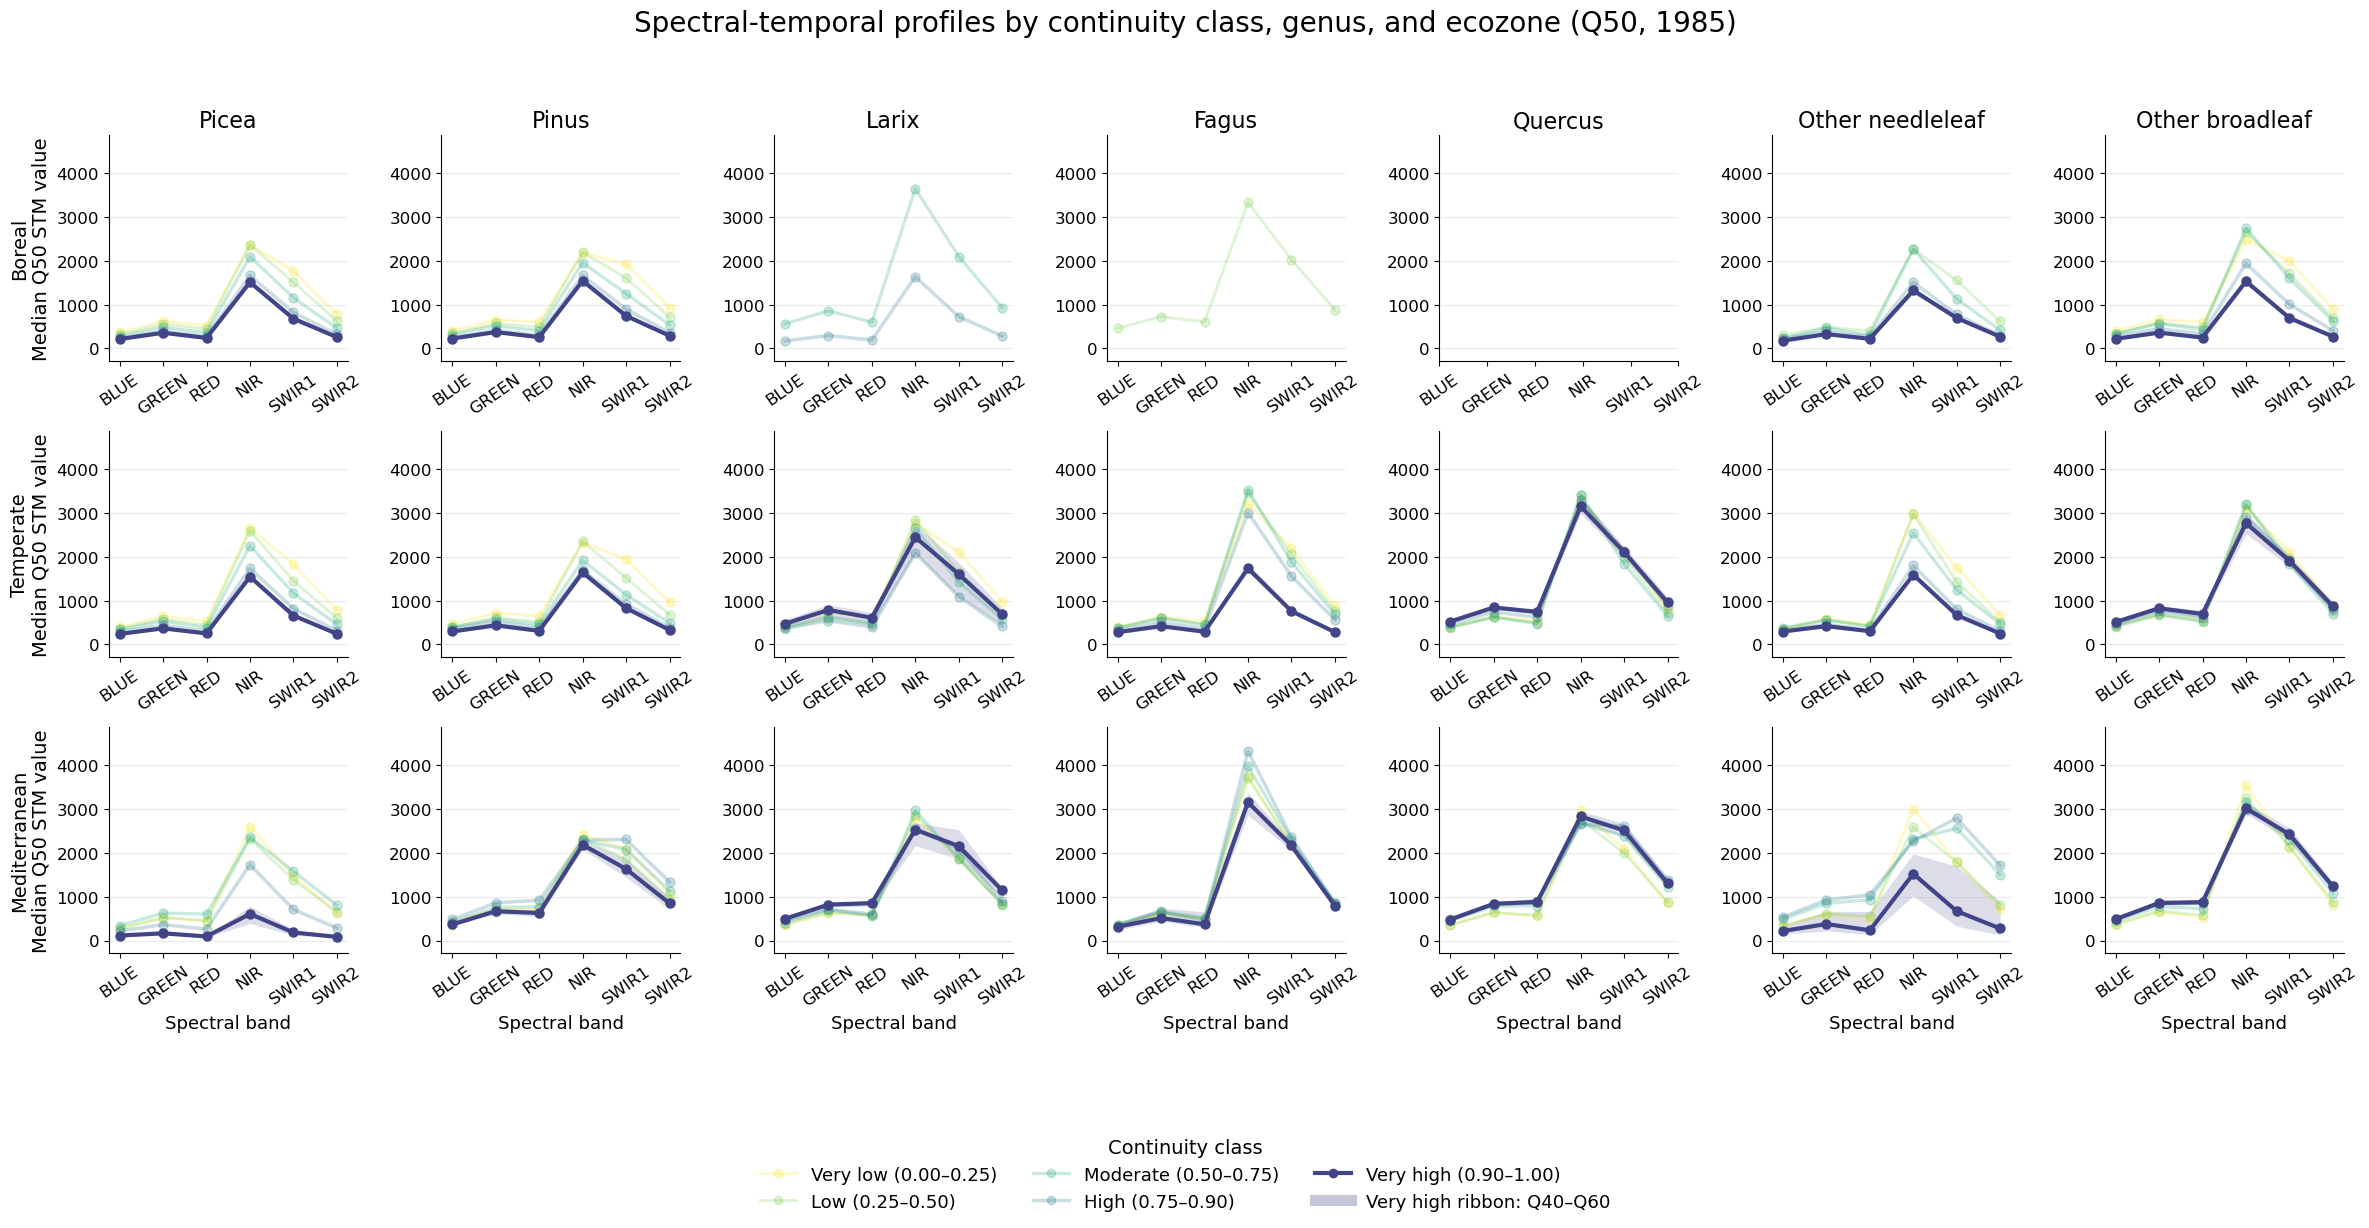

/mnt/eo/EO4Backcasting/_analysis_samples/spectral_profile_by_ecozone_and_genus_continuity_classes_Q50_1985_shared_yaxis.png


In [54]:
# ------------------------------------------------------------
# Spectral profile plot: Q50 by continuity class, genus, and ecozone
# one row per ecozone, one column per genus
# larger font sizes + increased spacing between panels and legend
# same y-axis limits for all subplots
# ------------------------------------------------------------

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

bands_plot = ["BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2"]
metric_plot = "Q50"

# Narrow ribbon range for the very high probability class
ribbon_lower = 0.40
ribbon_upper = 0.60

stm_cols_plot = [f"{band}_{metric_plot}" for band in bands_plot]

# Check whether required STM columns exist
missing = [col for col in stm_cols_plot if col not in df_analysis.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# ------------------------------------------------------------
# Make sure an ecoregion column exists
# ------------------------------------------------------------

df_plot = df_analysis.copy()

if "ecoregion" not in df_plot.columns:
    if "ecozone_code" in df_plot.columns:
        ecoregion_lookup = {
            1: "Boreal",
            2: "Temperate",
            3: "Mediterranean"
        }
        df_plot["ecoregion"] = df_plot["ecozone_code"].map(ecoregion_lookup)
    else:
        raise ValueError(
            "Neither 'ecoregion' nor 'ecozone_code' found in df_analysis."
        )

# ------------------------------------------------------------
# Define manual genus order
# ------------------------------------------------------------

genera_order = [
    "Picea",
    "Pinus",
    "Larix",
    "Fagus",
    "Quercus",
    "Other needleleaf",
    "Other broadleaf"
]

# Keep only genera actually present
genera_available = df_plot["genus"].dropna().unique().tolist()
genera_order = [g for g in genera_order if g in genera_available and g != "No trees"]

print("Genera shown in this order:")
print(genera_order)

# ------------------------------------------------------------
# Define ecozone order manually
# ------------------------------------------------------------

ecozone_order = ["Boreal", "Temperate", "Mediterranean"]

# Keep only ecozones actually present
ecozones_available = df_plot["ecoregion"].dropna().unique().tolist()
ecozone_order = [e for e in ecozone_order if e in ecozones_available]

print("Ecozones shown in this order:")
print(ecozone_order)

# ------------------------------------------------------------
# Probability classes and colors
# ------------------------------------------------------------

prob_order = [
    "very_low_0_025",
    "low_025_050",
    "moderate_050_075",
    "high_075_090",
    "very_high_090_100"
]

base_colors = {
    "very_low_0_025":    "#FDE725",
    "low_025_050":       "#7AD151",
    "moderate_050_075":  "#22A884",
    "high_075_090":      "#2A788E",
    "very_high_090_100": "#414487",
}

alpha_map = {
    "very_low_0_025": 0.25,
    "low_025_050": 0.25,
    "moderate_050_075": 0.25,
    "high_075_090": 0.25,
    "very_high_090_100": 1.00
}

plot_colors = {
    k: to_rgba(base_colors[k], alpha=alpha_map[k])
    for k in prob_order
}

linewidth_map = {
    "very_low_0_025": 2.0,
    "low_025_050": 2.0,
    "moderate_050_075": 2.3,
    "high_075_090": 2.5,
    "very_high_090_100": 3.0
}

legend_labels = {
    "very_low_0_025": "Very low (0.00–0.25)",
    "low_025_050": "Low (0.25–0.50)",
    "moderate_050_075": "Moderate (0.50–0.75)",
    "high_075_090": "High (0.75–0.90)",
    "very_high_090_100": "Very high (0.90–1.00)"
}

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

df_plot = df_plot[
    df_plot["genus"].isin(genera_order) &
    df_plot["ecoregion"].isin(ecozone_order) &
    df_plot["prob_class"].isin(prob_order)
].copy()

df_long = df_plot.melt(
    id_vars=["genus", "ecoregion", "prob_class", "probability"],
    value_vars=stm_cols_plot,
    var_name="band_metric",
    value_name="stm_value"
)

# Extract band name
df_long["band"] = (
    df_long["band_metric"]
    .str.replace(f"_{metric_plot}", "", regex=False)
)

df_long["band"] = pd.Categorical(
    df_long["band"],
    categories=bands_plot,
    ordered=True
)

df_long["prob_class"] = pd.Categorical(
    df_long["prob_class"],
    categories=prob_order,
    ordered=True
)

df_long["genus"] = pd.Categorical(
    df_long["genus"],
    categories=genera_order,
    ordered=True
)

df_long["ecoregion"] = pd.Categorical(
    df_long["ecoregion"],
    categories=ecozone_order,
    ordered=True
)

# Remove invalid values
df_long = df_long.replace([np.inf, -np.inf], np.nan)
df_long = df_long[df_long["stm_value"].notna()].copy()

# ------------------------------------------------------------
# Summary statistics by ecozone × genus × probability class × band
# ------------------------------------------------------------

df_summary = (
    df_long
    .groupby(["ecoregion", "genus", "prob_class", "band"], observed=True)["stm_value"]
    .agg(
        median="median",
        ribbon_low=lambda x: x.quantile(ribbon_lower),
        ribbon_high=lambda x: x.quantile(ribbon_upper)
    )
    .reset_index()
)

# Numeric x positions
band_to_x = {band: i for i, band in enumerate(bands_plot)}
df_summary["x"] = df_summary["band"].map(band_to_x)

# ------------------------------------------------------------
# Global y-axis limits for all subplots
# ------------------------------------------------------------

# Use all median lines and the very-high ribbon range for robust shared limits
y_values = pd.concat(
    [
        df_summary["median"],
        df_summary["ribbon_low"],
        df_summary["ribbon_high"]
    ],
    ignore_index=True
).replace([np.inf, -np.inf], np.nan).dropna()

y_min = y_values.min()
y_max = y_values.max()

y_range = y_max - y_min
y_pad = y_range * 0.08 if y_range > 0 else 1

y_lim = (y_min - y_pad, y_max + y_pad)

print("Shared y-axis limits:")
print(y_lim)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

nrows = len(ecozone_order)
ncols = len(genera_order)

fig_width = max(16, ncols * 3.4)
fig_height = max(10, nrows * 4.0)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(fig_width, fig_height),
    squeeze=False
)

# ------------------------------------------------------------
# Plot panels
# ------------------------------------------------------------

for r, ecozone in enumerate(ecozone_order):
    for c, genus in enumerate(genera_order):

        ax = axes[r, c]

        sub = df_summary[
            (df_summary["ecoregion"] == ecozone) &
            (df_summary["genus"] == genus)
        ].copy()

        # Add ribbon for the very high probability class
        sub_ribbon = sub[sub["prob_class"] == "very_high_090_100"].copy()
        sub_ribbon = sub_ribbon.sort_values("x")

        if not sub_ribbon.empty:
            ax.fill_between(
                sub_ribbon["x"].values,
                sub_ribbon["ribbon_low"].values,
                sub_ribbon["ribbon_high"].values,
                color=to_rgba(base_colors["very_high_090_100"], alpha=0.18),
                zorder=1,
                linewidth=0
            )

        # Plot lower classes first, very high last
        for prob_class in prob_order:
            sub_pc = sub[sub["prob_class"] == prob_class].copy()

            if sub_pc.empty:
                continue

            sub_pc = sub_pc.sort_values("x")

            ax.plot(
                sub_pc["x"].values,
                sub_pc["median"].values,
                color=plot_colors[prob_class],
                linewidth=linewidth_map[prob_class],
                marker="o",
                markersize=6.5,
                markerfacecolor=plot_colors[prob_class],
                markeredgecolor=plot_colors[prob_class],
                zorder=10 if prob_class == "very_high_090_100" else 5
            )

        # Same y-axis for all panels
        ax.set_ylim(y_lim)

        # Column titles only in top row
        if r == 0:
            ax.set_title(genus, fontsize=16)

        # Row labels only in first column
        if c == 0:
            ax.set_ylabel(f"{ecozone}\nMedian {metric_plot} STM value", fontsize=14)
        else:
            ax.set_ylabel("")

        # X labels only in bottom row
        if r == nrows - 1:
            ax.set_xlabel("Spectral band", fontsize=13)
        else:
            ax.set_xlabel("")

        ax.set_xticks(range(len(bands_plot)))
        ax.set_xticklabels(bands_plot, rotation=35)

        ax.tick_params(axis="x", labelsize=12)
        ax.tick_params(axis="y", labelsize=12)

        ax.grid(True, axis="y", alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Global legend below all panels with larger spacing
# ------------------------------------------------------------

legend_handles = [
    Line2D(
        [0], [0],
        color=plot_colors[k],
        marker="o",
        markerfacecolor=plot_colors[k],
        markeredgecolor=plot_colors[k],
        linewidth=linewidth_map[k],
        label=legend_labels[k]
    )
    for k in prob_order
]

legend_handles.append(
    Line2D(
        [0], [0],
        color=to_rgba(base_colors["very_high_090_100"], alpha=0.30),
        linewidth=8,
        label=f"Very high ribbon: Q{int(ribbon_lower * 100)}–Q{int(ribbon_upper * 100)}"
    )
)

fig.legend(
    handles=legend_handles,
    title="Continuity class",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    frameon=False,
    fontsize=13,
    title_fontsize=14,
    ncol=3
)

# ------------------------------------------------------------
# Title and layout
# ------------------------------------------------------------

fig.suptitle(
    f"Spectral-temporal profiles by continuity class, genus, and ecozone ({metric_plot}, {stm_year})",
    fontsize=20,
    y=0.995
)

# Increase bottom margin to create more distance between panels and legend
plt.tight_layout(rect=[0, 0.13, 1, 0.96])

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

out_plot_fp = os.path.join(
    out_dir,
    f"spectral_profile_by_ecozone_and_genus_continuity_classes_{metric_plot}_{stm_year}_shared_yaxis.png"
)

plt.savefig(out_plot_fp, dpi=300, bbox_inches="tight")
plt.show()

print(out_plot_fp)

Genera shown:
['Picea', 'Pinus', 'Larix', 'Fagus', 'Quercus', 'Other needleleaf', 'Other broadleaf']
Ecozones shown:
['Boreal', 'Temperate', 'Mediterranean']
Samples used: 150000


,genus,ecoregion,n_samples
0,Fagus,Mediterranean,479
1,Fagus,Temperate,949
2,Larix,Mediterranean,22
3,Larix,Temperate,128
4,Other broadleaf,Boreal,4802
5,Other broadleaf,Mediterranean,17084
6,Other broadleaf,Temperate,6796
7,Other needleleaf,Boreal,6
8,Other needleleaf,Mediterranean,1070
9,Other needleleaf,Temperate,1354


Shared y-axis limits:
(-197.86399999999992, 3625.264)


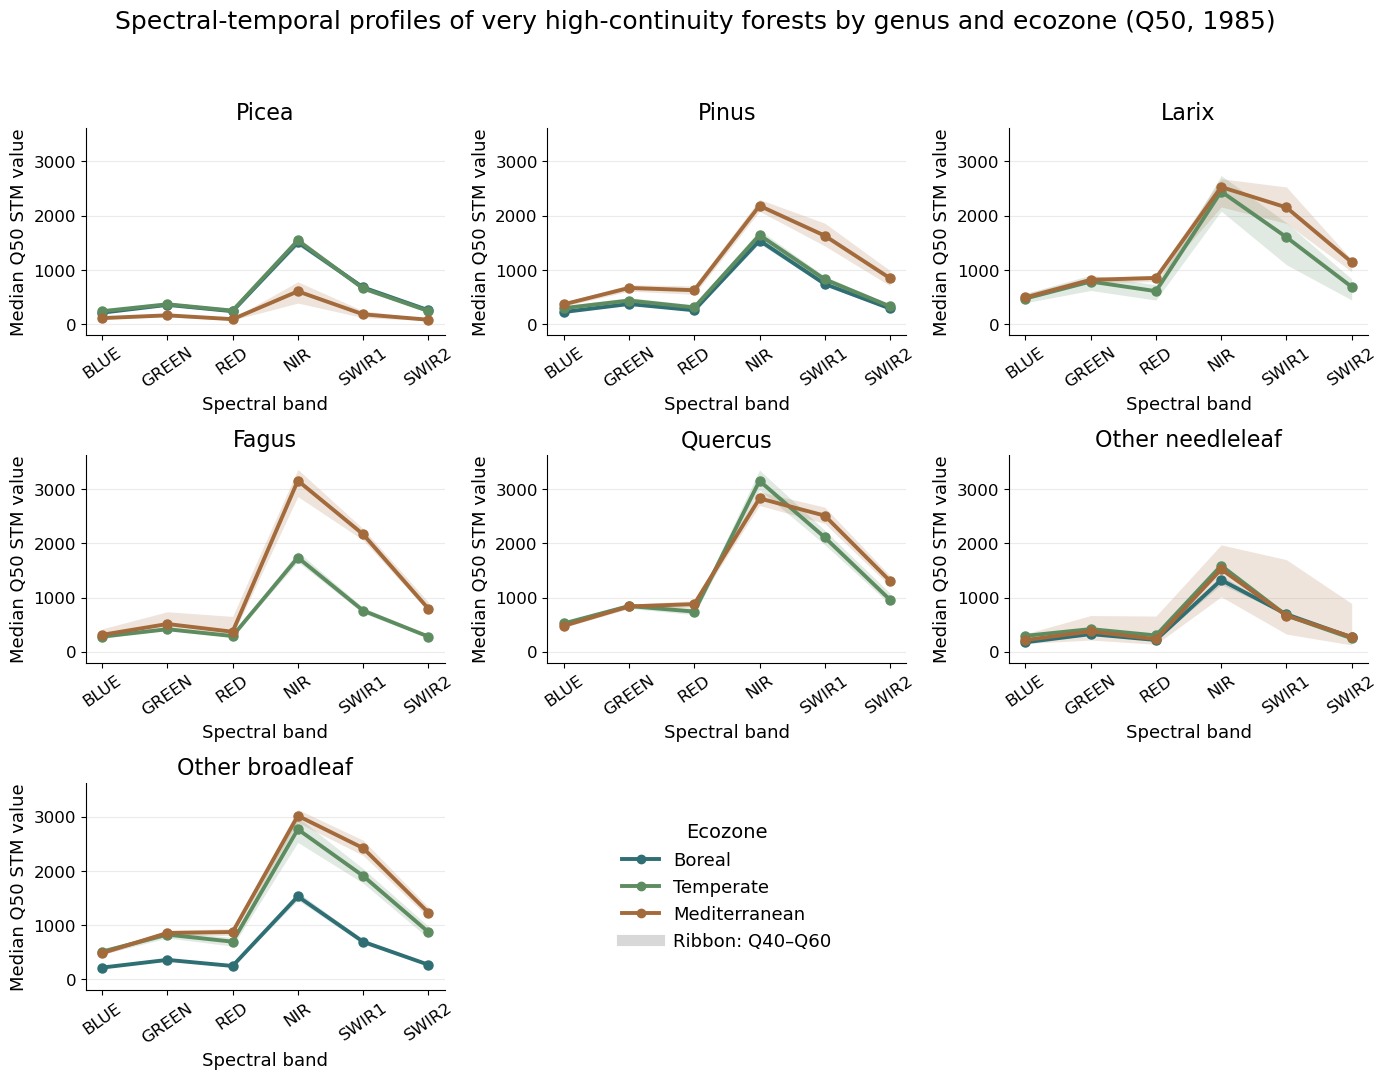

/mnt/eo/EO4Backcasting/_analysis_samples/spectral_profile_very_high_continuity_by_genus_and_ecozone_Q50_1985_shared_yaxis.png


In [53]:
# ------------------------------------------------------------
# Spectral profile plot: very high continuity forests by genus and ecozone
# with petrol, green, and brown ecozone colors
# same y-axis limits for all subplots
# ------------------------------------------------------------

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

bands_plot = ["BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2"]
metric_plot = "Q50"

# Only show the highest probability class
target_prob_class = "very_high_090_100"

# Narrow ribbon range
ribbon_lower = 0.40
ribbon_upper = 0.60

stm_cols_plot = [f"{band}_{metric_plot}" for band in bands_plot]

# Check whether required STM columns exist
missing = [col for col in stm_cols_plot if col not in df_analysis.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# ------------------------------------------------------------
# Prepare dataframe and ecoregion column
# ------------------------------------------------------------

df_plot = df_analysis.copy()

# Create readable ecoregion names if only ecozone_code exists
if "ecoregion" not in df_plot.columns:
    if "ecozone_code" in df_plot.columns:
        ecoregion_lookup = {
            1: "Boreal",
            2: "Temperate",
            3: "Mediterranean"
        }
        df_plot["ecoregion"] = df_plot["ecozone_code"].map(ecoregion_lookup)
    else:
        raise ValueError(
            "Neither 'ecoregion' nor 'ecozone_code' found in df_analysis."
        )

# ------------------------------------------------------------
# Manual order of genera and ecozones
# ------------------------------------------------------------

genera_order = [
    "Picea",
    "Pinus",
    "Larix",
    "Fagus",
    "Quercus",
    "Other needleleaf",
    "Other broadleaf"
]

genera_available = df_plot["genus"].dropna().unique().tolist()
genera_order = [g for g in genera_order if g in genera_available and g != "No trees"]

ecozone_order = ["Boreal", "Temperate", "Mediterranean"]

ecozones_available = df_plot["ecoregion"].dropna().unique().tolist()
ecozone_order = [e for e in ecozone_order if e in ecozones_available]

print("Genera shown:")
print(genera_order)

print("Ecozones shown:")
print(ecozone_order)

# ------------------------------------------------------------
# Ecozone colors
# Boreal = petrol
# Temperate = green
# Mediterranean = brown
# ------------------------------------------------------------

ecozone_colors = {
    "Boreal": "#2F6F73",         # petrol
    "Temperate": "#5E8C61",      # green
    "Mediterranean": "#A36A3C"   # brown
}

# Transparent ribbon colors
ecozone_ribbon_colors = {
    eco: to_rgba(ecozone_colors[eco], alpha=0.18)
    for eco in ecozone_order
}

# ------------------------------------------------------------
# Filter to very high continuity class
# ------------------------------------------------------------

df_plot = df_plot[
    (df_plot["prob_class"] == target_prob_class) &
    (df_plot["genus"].isin(genera_order)) &
    (df_plot["ecoregion"].isin(ecozone_order))
].copy()

print("Samples used:", len(df_plot))

display(
    df_plot
    .groupby(["genus", "ecoregion"])
    .size()
    .reset_index(name="n_samples")
    .sort_values(["genus", "ecoregion"])
)

# ------------------------------------------------------------
# Convert to long format
# ------------------------------------------------------------

df_long = df_plot.melt(
    id_vars=["genus", "ecoregion", "prob_class", "probability"],
    value_vars=stm_cols_plot,
    var_name="band_metric",
    value_name="stm_value"
)

df_long["band"] = (
    df_long["band_metric"]
    .str.replace(f"_{metric_plot}", "", regex=False)
)

df_long["band"] = pd.Categorical(
    df_long["band"],
    categories=bands_plot,
    ordered=True
)

df_long["genus"] = pd.Categorical(
    df_long["genus"],
    categories=genera_order,
    ordered=True
)

df_long["ecoregion"] = pd.Categorical(
    df_long["ecoregion"],
    categories=ecozone_order,
    ordered=True
)

df_long = df_long.replace([np.inf, -np.inf], np.nan)
df_long = df_long[df_long["stm_value"].notna()].copy()

# ------------------------------------------------------------
# Summary statistics by genus × ecozone × band
# ------------------------------------------------------------

df_summary = (
    df_long
    .groupby(["genus", "ecoregion", "band"], observed=True)["stm_value"]
    .agg(
        median="median",
        ribbon_low=lambda x: x.quantile(ribbon_lower),
        ribbon_high=lambda x: x.quantile(ribbon_upper),
        n="count"
    )
    .reset_index()
)

# Numeric x positions
band_to_x = {band: i for i, band in enumerate(bands_plot)}
df_summary["x"] = df_summary["band"].map(band_to_x)

# ------------------------------------------------------------
# Global y-axis limits for all subplots
# ------------------------------------------------------------

y_min = df_summary["ribbon_low"].min()
y_max = df_summary["ribbon_high"].max()

# Add small padding so ribbons/points do not touch plot borders
y_range = y_max - y_min
y_pad = y_range * 0.08

y_lim = (y_min - y_pad, y_max + y_pad)

print("Shared y-axis limits:")
print(y_lim)

# ------------------------------------------------------------
# Create multi-panel figure: one panel per genus
# ------------------------------------------------------------

n_panels = len(genera_order)
ncols = 3
nrows = math.ceil((n_panels + 1) / ncols)  # +1 for legend panel

fig_width = 14
fig_height = max(7, nrows * 3.6)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(fig_width, fig_height),
    squeeze=False
)

axes_flat = axes.flatten()

# ------------------------------------------------------------
# Plot one genus per panel
# ------------------------------------------------------------

for i, genus in enumerate(genera_order):

    ax = axes_flat[i]

    sub_genus = df_summary[df_summary["genus"] == genus].copy()

    for ecozone in ecozone_order:

        sub = sub_genus[sub_genus["ecoregion"] == ecozone].copy()

        if sub.empty:
            continue

        sub = sub.sort_values("x")

        # Ribbon
        ax.fill_between(
            sub["x"].values,
            sub["ribbon_low"].values,
            sub["ribbon_high"].values,
            color=ecozone_ribbon_colors[ecozone],
            zorder=1,
            linewidth=0
        )

        # Median line
        ax.plot(
            sub["x"].values,
            sub["median"].values,
            color=ecozone_colors[ecozone],
            linewidth=2.8,
            marker="o",
            markersize=6.5,
            markerfacecolor=ecozone_colors[ecozone],
            markeredgecolor=ecozone_colors[ecozone],
            label=ecozone,
            zorder=5
        )

    ax.set_title(genus, fontsize=16)
    ax.set_xlabel("Spectral band", fontsize=13)
    ax.set_ylabel(f"Median {metric_plot} STM value", fontsize=13)

    ax.set_xticks(range(len(bands_plot)))
    ax.set_xticklabels(bands_plot, rotation=35)

    # Same y-axis for all genus panels
    ax.set_ylim(y_lim)

    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)

    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Legend in first empty panel
# ------------------------------------------------------------

legend_ax = axes_flat[n_panels]
legend_ax.axis("off")

legend_handles = [
    Line2D(
        [0], [0],
        color=ecozone_colors[eco],
        marker="o",
        markerfacecolor=ecozone_colors[eco],
        markeredgecolor=ecozone_colors[eco],
        linewidth=2.8,
        label=eco
    )
    for eco in ecozone_order
]

legend_handles.append(
    Line2D(
        [0], [0],
        color=to_rgba("#666666", alpha=0.25),
        linewidth=8,
        label=f"Ribbon: Q{int(ribbon_lower * 100)}–Q{int(ribbon_upper * 100)}"
    )
)

legend_ax.legend(
    handles=legend_handles,
    title="Ecozone",
    loc="center",
    frameon=False,
    fontsize=13,
    title_fontsize=14,
    ncol=1
)

# Hide remaining empty axes
for j in range(n_panels + 1, len(axes_flat)):
    axes_flat[j].axis("off")

# ------------------------------------------------------------
# Title and layout
# ------------------------------------------------------------

fig.suptitle(
    f"Spectral-temporal profiles of very high-continuity forests by genus and ecozone ({metric_plot}, {stm_year})",
    fontsize=18,
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

out_plot_fp = os.path.join(
    out_dir,
    f"spectral_profile_very_high_continuity_by_genus_and_ecozone_{metric_plot}_{stm_year}_shared_yaxis.png"
)

plt.savefig(out_plot_fp, dpi=300, bbox_inches="tight")
plt.show()

print(out_plot_fp)

Using metric: Q90
Genera shown:
['Picea', 'Pinus', 'Larix', 'Fagus', 'Quercus', 'Other needleleaf', 'Other broadleaf']
Ecozones shown:
['Boreal', 'Temperate', 'Mediterranean']
Samples used: 150000


,genus,ecoregion,n_samples
0,Fagus,Mediterranean,479
1,Fagus,Temperate,949
2,Larix,Mediterranean,22
3,Larix,Temperate,128
4,Other broadleaf,Boreal,4802
5,Other broadleaf,Mediterranean,17084
6,Other broadleaf,Temperate,6796
7,Other needleleaf,Boreal,6
8,Other needleleaf,Mediterranean,1070
9,Other needleleaf,Temperate,1354


Shared y-axis limits:
(-257.7519999999999, 4433.7519999999995)


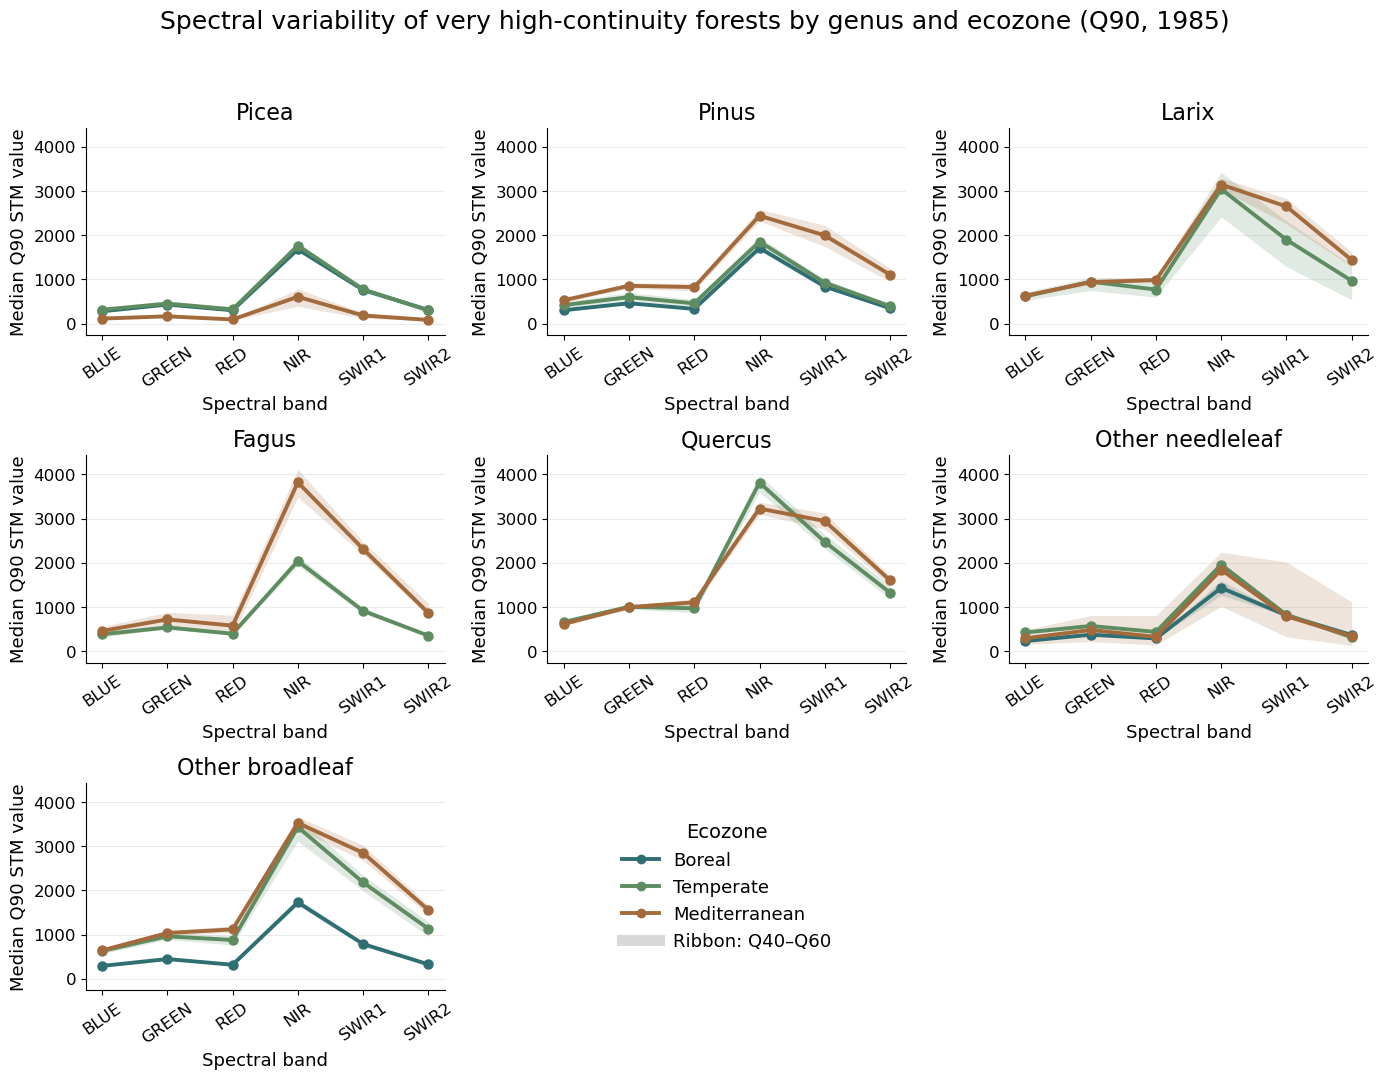

/mnt/eo/EO4Backcasting/_analysis_samples/spectral_variability_very_high_continuity_by_genus_and_ecozone_Q90_1985_shared_yaxis.png


In [56]:
# ------------------------------------------------------------
# Spectral profile plot: spectral variability (SD / STD / selected metric)
# of very high continuity forests by genus and ecozone
# one panel per genus
# same y-axis limits for all subplots
# ------------------------------------------------------------

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

bands_plot = ["BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2"]

# Use the metric name that exists in your dataframe.
# FORCE usually uses "STD". If your columns are BLUE_SD etc., change this to "SD".
preferred_metric = "Q90"

# Only show the highest probability class
target_prob_class = "very_high_090_100"

# Narrow ribbon range
ribbon_lower = 0.40
ribbon_upper = 0.60

# ------------------------------------------------------------
# Detect whether preferred metric / STD / SD exists
# ------------------------------------------------------------

candidate_metrics = [preferred_metric, "STD", "SD"]

metric_plot = None
for cand in candidate_metrics:
    test_cols = [f"{band}_{cand}" for band in bands_plot]
    if all(col in df_analysis.columns for col in test_cols):
        metric_plot = cand
        break

if metric_plot is None:
    raise ValueError(
        "Could not find the requested metric columns in df_analysis.\n"
        "Checked for:\n"
        + "\n".join(
            [", ".join([f"{band}_{cand}" for band in bands_plot]) for cand in candidate_metrics]
        )
    )

stm_cols_plot = [f"{band}_{metric_plot}" for band in bands_plot]

print(f"Using metric: {metric_plot}")

# ------------------------------------------------------------
# Prepare dataframe and ecoregion column
# ------------------------------------------------------------

df_plot = df_analysis.copy()

if "ecoregion" not in df_plot.columns:
    if "ecozone_code" in df_plot.columns:
        ecoregion_lookup = {
            1: "Boreal",
            2: "Temperate",
            3: "Mediterranean"
        }
        df_plot["ecoregion"] = df_plot["ecozone_code"].map(ecoregion_lookup)
    else:
        raise ValueError(
            "Neither 'ecoregion' nor 'ecozone_code' found in df_analysis."
        )

# ------------------------------------------------------------
# Manual order of genera and ecozones
# ------------------------------------------------------------

genera_order = [
    "Picea",
    "Pinus",
    "Larix",
    "Fagus",
    "Quercus",
    "Other needleleaf",
    "Other broadleaf"
]

genera_available = df_plot["genus"].dropna().unique().tolist()
genera_order = [g for g in genera_order if g in genera_available and g != "No trees"]

ecozone_order = ["Boreal", "Temperate", "Mediterranean"]

ecozones_available = df_plot["ecoregion"].dropna().unique().tolist()
ecozone_order = [e for e in ecozone_order if e in ecozones_available]

print("Genera shown:")
print(genera_order)

print("Ecozones shown:")
print(ecozone_order)

# ------------------------------------------------------------
# Ecozone colors
# Boreal = petrol
# Temperate = green
# Mediterranean = brown
# ------------------------------------------------------------

ecozone_colors = {
    "Boreal": "#2F6F73",
    "Temperate": "#5E8C61",
    "Mediterranean": "#A36A3C"
}

ecozone_ribbon_colors = {
    eco: to_rgba(ecozone_colors[eco], alpha=0.18)
    for eco in ecozone_order
}

# ------------------------------------------------------------
# Filter to very high continuity class
# ------------------------------------------------------------

df_plot = df_plot[
    (df_plot["prob_class"] == target_prob_class) &
    (df_plot["genus"].isin(genera_order)) &
    (df_plot["ecoregion"].isin(ecozone_order))
].copy()

print("Samples used:", len(df_plot))

display(
    df_plot
    .groupby(["genus", "ecoregion"])
    .size()
    .reset_index(name="n_samples")
    .sort_values(["genus", "ecoregion"])
)

# ------------------------------------------------------------
# Convert to long format
# ------------------------------------------------------------

df_long = df_plot.melt(
    id_vars=["genus", "ecoregion", "prob_class", "probability"],
    value_vars=stm_cols_plot,
    var_name="band_metric",
    value_name="stm_value"
)

df_long["band"] = (
    df_long["band_metric"]
    .str.replace(f"_{metric_plot}", "", regex=False)
)

df_long["band"] = pd.Categorical(
    df_long["band"],
    categories=bands_plot,
    ordered=True
)

df_long["genus"] = pd.Categorical(
    df_long["genus"],
    categories=genera_order,
    ordered=True
)

df_long["ecoregion"] = pd.Categorical(
    df_long["ecoregion"],
    categories=ecozone_order,
    ordered=True
)

df_long = df_long.replace([np.inf, -np.inf], np.nan)
df_long = df_long[df_long["stm_value"].notna()].copy()

# ------------------------------------------------------------
# Summary statistics by genus × ecozone × band
# ------------------------------------------------------------

df_summary = (
    df_long
    .groupby(["genus", "ecoregion", "band"], observed=True)["stm_value"]
    .agg(
        median="median",
        ribbon_low=lambda x: x.quantile(ribbon_lower),
        ribbon_high=lambda x: x.quantile(ribbon_upper),
        n="count"
    )
    .reset_index()
)

band_to_x = {band: i for i, band in enumerate(bands_plot)}
df_summary["x"] = df_summary["band"].map(band_to_x)

# ------------------------------------------------------------
# Global y-axis limits for all subplots
# ------------------------------------------------------------

y_values = pd.concat(
    [
        df_summary["median"],
        df_summary["ribbon_low"],
        df_summary["ribbon_high"]
    ],
    ignore_index=True
).replace([np.inf, -np.inf], np.nan).dropna()

y_min = y_values.min()
y_max = y_values.max()

y_range = y_max - y_min
y_pad = y_range * 0.08 if y_range > 0 else 1

y_lim = (y_min - y_pad, y_max + y_pad)

print("Shared y-axis limits:")
print(y_lim)

# ------------------------------------------------------------
# Create multi-panel figure: one panel per genus
# ------------------------------------------------------------

n_panels = len(genera_order)
ncols = 3
nrows = math.ceil((n_panels + 1) / ncols)  # +1 for legend panel

fig_width = 14
fig_height = max(7, nrows * 3.6)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(fig_width, fig_height),
    squeeze=False
)

axes_flat = axes.flatten()

# ------------------------------------------------------------
# Plot one genus per panel
# ------------------------------------------------------------

for i, genus in enumerate(genera_order):

    ax = axes_flat[i]

    sub_genus = df_summary[df_summary["genus"] == genus].copy()

    for ecozone in ecozone_order:

        sub = sub_genus[sub_genus["ecoregion"] == ecozone].copy()

        if sub.empty:
            continue

        sub = sub.sort_values("x")

        # Ribbon
        ax.fill_between(
            sub["x"].values,
            sub["ribbon_low"].values,
            sub["ribbon_high"].values,
            color=ecozone_ribbon_colors[ecozone],
            zorder=1,
            linewidth=0
        )

        # Median line
        ax.plot(
            sub["x"].values,
            sub["median"].values,
            color=ecozone_colors[ecozone],
            linewidth=2.8,
            marker="o",
            markersize=6.5,
            markerfacecolor=ecozone_colors[ecozone],
            markeredgecolor=ecozone_colors[ecozone],
            label=ecozone,
            zorder=5
        )

    # Same y-axis for all panels
    ax.set_ylim(y_lim)

    ax.set_title(genus, fontsize=16)
    ax.set_xlabel("Spectral band", fontsize=13)
    ax.set_ylabel(f"Median {metric_plot} STM value", fontsize=13)

    ax.set_xticks(range(len(bands_plot)))
    ax.set_xticklabels(bands_plot, rotation=35)

    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)

    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Legend in first empty panel
# ------------------------------------------------------------

legend_ax = axes_flat[n_panels]
legend_ax.axis("off")

legend_handles = [
    Line2D(
        [0], [0],
        color=ecozone_colors[eco],
        marker="o",
        markerfacecolor=ecozone_colors[eco],
        markeredgecolor=ecozone_colors[eco],
        linewidth=2.8,
        label=eco
    )
    for eco in ecozone_order
]

legend_handles.append(
    Line2D(
        [0], [0],
        color=to_rgba("#666666", alpha=0.25),
        linewidth=8,
        label=f"Ribbon: Q{int(ribbon_lower * 100)}–Q{int(ribbon_upper * 100)}"
    )
)

legend_ax.legend(
    handles=legend_handles,
    title="Ecozone",
    loc="center",
    frameon=False,
    fontsize=13,
    title_fontsize=14,
    ncol=1
)

# Hide remaining empty axes
for j in range(n_panels + 1, len(axes_flat)):
    axes_flat[j].axis("off")

# ------------------------------------------------------------
# Title and layout
# ------------------------------------------------------------

fig.suptitle(
    f"Spectral variability of very high-continuity forests by genus and ecozone ({metric_plot}, {stm_year})",
    fontsize=18,
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

out_plot_fp = os.path.join(
    out_dir,
    f"spectral_variability_very_high_continuity_by_genus_and_ecozone_{metric_plot}_{stm_year}_shared_yaxis.png"
)

plt.savefig(out_plot_fp, dpi=300, bbox_inches="tight")
plt.show()

print(out_plot_fp)

Using metrics:
Q50 metric: Q50
STD metric: STD
Genera shown:
['Picea', 'Pinus', 'Larix', 'Fagus', 'Quercus', 'Other needleleaf', 'Other broadleaf']
Ecozones shown:
['Boreal', 'Temperate', 'Mediterranean']
Samples used: 150000


,ecoregion,genus,n_samples
0,Boreal,Other broadleaf,4802
1,Boreal,Other needleleaf,6
2,Boreal,Picea,36089
3,Boreal,Pinus,9103
4,Mediterranean,Fagus,479
5,Mediterranean,Larix,22
6,Mediterranean,Other broadleaf,17084
7,Mediterranean,Other needleleaf,1070
8,Mediterranean,Picea,2570
9,Mediterranean,Pinus,12412


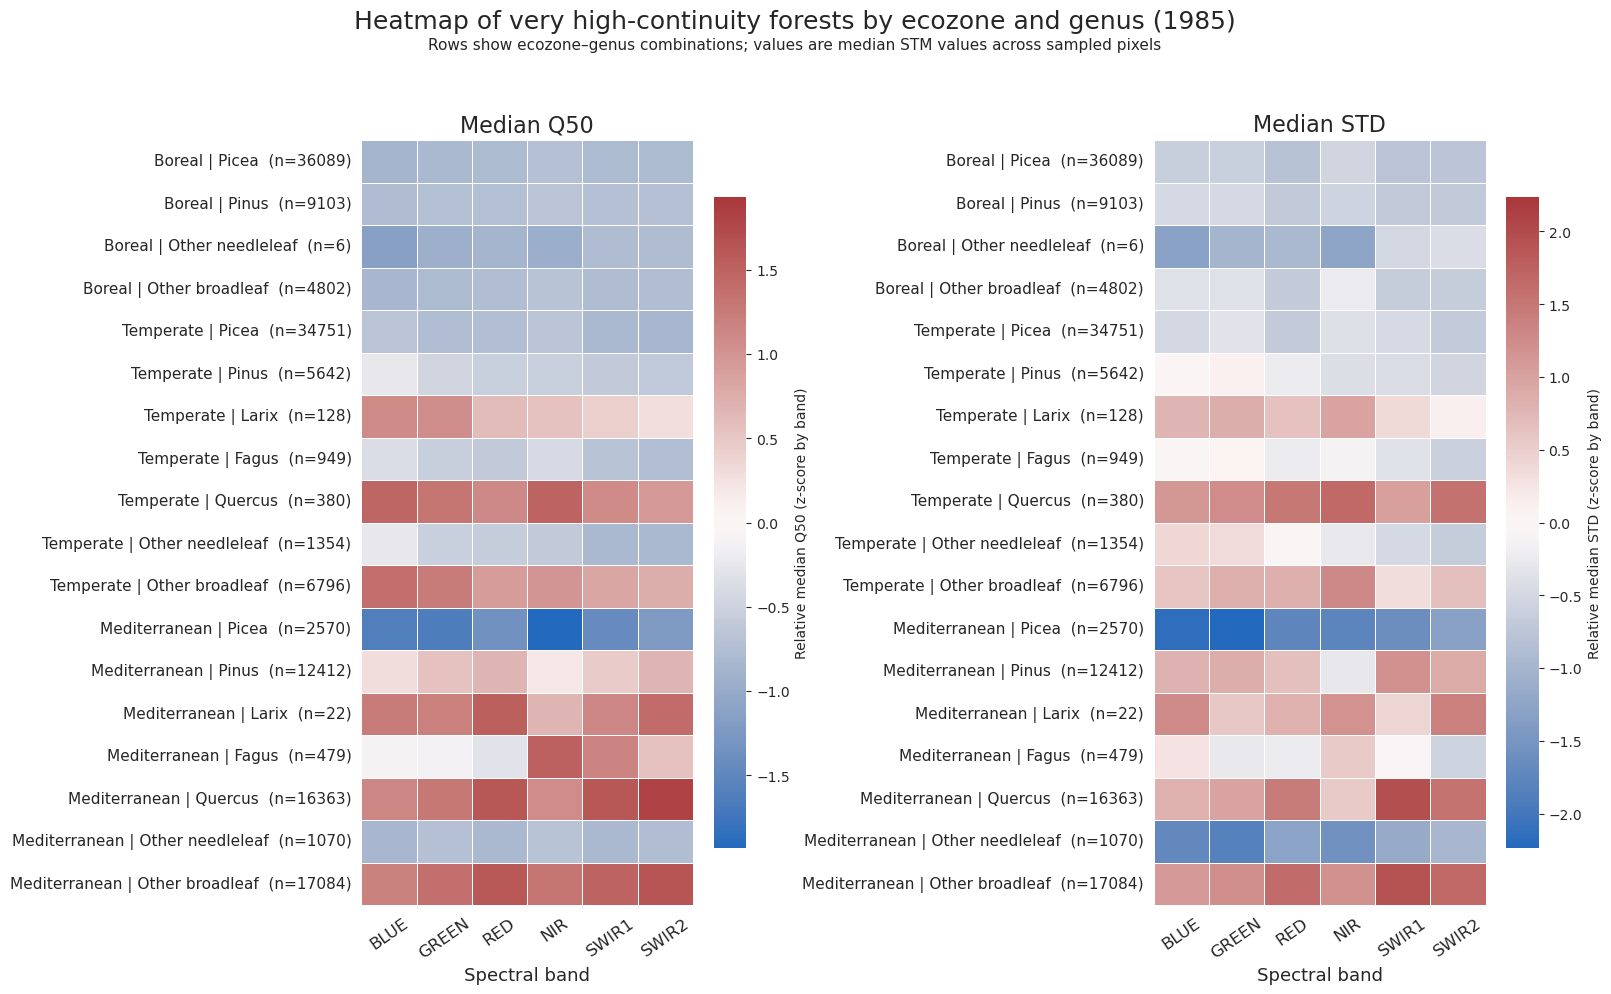

/mnt/eo/EO4Backcasting/_analysis_samples/heatmap_very_high_continuity_ecozone_genus_Q50_STD_1985_standardized.png


In [59]:
# ------------------------------------------------------------
# Heatmap of very high-continuity forests by ecozone and genus
# showing Q50 and STD (or SD) side by side
# ------------------------------------------------------------

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

bands_plot = ["BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2"]
target_prob_class = "very_high_090_100"

# Set to True if you want relative patterns to stand out more.
# Then each heatmap column is z-standardized across rows.
# Set to False if you want raw median STM values.
standardize = True

# Manual order
genera_order = [
    "Picea",
    "Pinus",
    "Larix",
    "Fagus",
    "Quercus",
    "Other needleleaf",
    "Other broadleaf"
]

ecozone_order = ["Boreal", "Temperate", "Mediterranean"]

# ------------------------------------------------------------
# Detect metric names
# ------------------------------------------------------------

def detect_metric(df, bands, preferred_candidates):
    """
    Detect which metric name exists in the dataframe, e.g. Q50, STD, SD.
    Returns the first matching candidate.
    """
    for cand in preferred_candidates:
        cols = [f"{band}_{cand}" for band in bands]
        if all(col in df.columns for col in cols):
            return cand
    return None

metric_q50 = detect_metric(df_analysis, bands_plot, ["Q50"])
metric_std = detect_metric(df_analysis, bands_plot, ["STD", "SD"])

if metric_q50 is None:
    raise ValueError(
        "Could not find Q50 columns in df_analysis.\n"
        f"Expected columns like: {[f'{b}_Q50' for b in bands_plot]}"
    )

if metric_std is None:
    raise ValueError(
        "Could not find STD/SD columns in df_analysis.\n"
        f"Checked: {[f'{b}_STD' for b in bands_plot]} and {[f'{b}_SD' for b in bands_plot]}"
    )

print("Using metrics:")
print("Q50 metric:", metric_q50)
print("STD metric:", metric_std)

q50_cols = [f"{band}_{metric_q50}" for band in bands_plot]
std_cols = [f"{band}_{metric_std}" for band in bands_plot]

# ------------------------------------------------------------
# Prepare dataframe and ecoregion column
# ------------------------------------------------------------

df_plot = df_analysis.copy()

if "ecoregion" not in df_plot.columns:
    if "ecozone_code" in df_plot.columns:
        ecoregion_lookup = {
            1: "Boreal",
            2: "Temperate",
            3: "Mediterranean"
        }
        df_plot["ecoregion"] = df_plot["ecozone_code"].map(ecoregion_lookup)
    else:
        raise ValueError(
            "Neither 'ecoregion' nor 'ecozone_code' found in df_analysis."
        )

# Keep only genera and ecozones actually present
genera_available = df_plot["genus"].dropna().unique().tolist()
genera_order = [g for g in genera_order if g in genera_available and g != "No trees"]

ecozones_available = df_plot["ecoregion"].dropna().unique().tolist()
ecozone_order = [e for e in ecozone_order if e in ecozones_available]

print("Genera shown:")
print(genera_order)

print("Ecozones shown:")
print(ecozone_order)

# ------------------------------------------------------------
# Filter to very high continuity class
# ------------------------------------------------------------

df_plot = df_plot[
    (df_plot["prob_class"] == target_prob_class) &
    (df_plot["genus"].isin(genera_order)) &
    (df_plot["ecoregion"].isin(ecozone_order))
].copy()

print("Samples used:", len(df_plot))

display(
    df_plot
    .groupby(["ecoregion", "genus"])
    .size()
    .reset_index(name="n_samples")
    .sort_values(["ecoregion", "genus"])
)

# ------------------------------------------------------------
# Aggregate median Q50 and median STD/SD
# ------------------------------------------------------------

agg_dict = {col: "median" for col in q50_cols + std_cols}

df_summary = (
    df_plot
    .groupby(["ecoregion", "genus"], as_index=False)
    .agg(agg_dict)
)

# Add counts as optional information
df_counts = (
    df_plot
    .groupby(["ecoregion", "genus"])
    .size()
    .reset_index(name="n_samples")
)

df_summary = df_summary.merge(df_counts, on=["ecoregion", "genus"], how="left")

# ------------------------------------------------------------
# Enforce row order
# ------------------------------------------------------------

row_order = [(eco, gen) for eco in ecozone_order for gen in genera_order]

df_summary["row_key"] = list(zip(df_summary["ecoregion"], df_summary["genus"]))
df_summary = df_summary[df_summary["row_key"].isin(row_order)].copy()

row_order_present = [rk for rk in row_order if rk in df_summary["row_key"].tolist()]

df_summary["row_key"] = pd.Categorical(
    df_summary["row_key"],
    categories=row_order_present,
    ordered=True
)

df_summary = df_summary.sort_values("row_key").copy()

# Pretty row labels, optionally including sample size
df_summary["row_label"] = (
    df_summary["ecoregion"].astype(str)
    + " | "
    + df_summary["genus"].astype(str)
    + "  (n="
    + df_summary["n_samples"].astype(str)
    + ")"
)

# ------------------------------------------------------------
# Build heatmap matrices
# ------------------------------------------------------------

q50_matrix = df_summary[q50_cols].copy()
q50_matrix.columns = bands_plot
q50_matrix.index = df_summary["row_label"]

std_matrix = df_summary[std_cols].copy()
std_matrix.columns = bands_plot
std_matrix.index = df_summary["row_label"]

# ------------------------------------------------------------
# Optional standardization
# ------------------------------------------------------------

def zscore_columns(df):
    """
    Z-standardize each column separately.
    """
    df_z = df.copy().astype(float)
    for col in df_z.columns:
        col_std = df_z[col].std()
        if pd.isna(col_std) or col_std == 0:
            df_z[col] = 0.0
        else:
            df_z[col] = (df_z[col] - df_z[col].mean()) / col_std
    return df_z

if standardize:
    q50_plot = zscore_columns(q50_matrix)
    std_plot = zscore_columns(std_matrix)
    cbar_label_q50 = "Relative median Q50 (z-score by band)"
    cbar_label_std = f"Relative median {metric_std} (z-score by band)"
else:
    q50_plot = q50_matrix.copy()
    std_plot = std_matrix.copy()
    cbar_label_q50 = "Median Q50 STM value"
    cbar_label_std = f"Median {metric_std} STM value"

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, max(8, 0.45 * len(q50_plot) + 2)),
    constrained_layout=False
)

# Shared heatmap settings
heatmap_kwargs = dict(
    cmap="vlag",
    linewidths=0.5,
    linecolor="white",
    cbar=True
)

# Symmetric color limits for standardized heatmaps
if standardize:
    vmax_q50 = np.nanmax(np.abs(q50_plot.values))
    vmax_std = np.nanmax(np.abs(std_plot.values))
    vmax_q50 = max(1.0, vmax_q50)
    vmax_std = max(1.0, vmax_std)

    sns.heatmap(
        q50_plot,
        ax=axes[0],
        vmin=-vmax_q50,
        vmax=vmax_q50,
        center=0,
        cbar_kws={"label": cbar_label_q50, "shrink": 0.85},
        **heatmap_kwargs
    )

    sns.heatmap(
        std_plot,
        ax=axes[1],
        vmin=-vmax_std,
        vmax=vmax_std,
        center=0,
        cbar_kws={"label": cbar_label_std, "shrink": 0.85},
        **heatmap_kwargs
    )
else:
    sns.heatmap(
        q50_plot,
        ax=axes[0],
        cbar_kws={"label": cbar_label_q50, "shrink": 0.85},
        **heatmap_kwargs
    )

    sns.heatmap(
        std_plot,
        ax=axes[1],
        cbar_kws={"label": cbar_label_std, "shrink": 0.85},
        **heatmap_kwargs
    )

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

axes[0].set_title(
    f"Median {metric_q50}",
    fontsize=16
)

axes[1].set_title(
    f"Median {metric_std}",
    fontsize=16
)

for ax in axes:
    ax.set_xlabel("Spectral band", fontsize=13)
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=12, rotation=35)
    ax.tick_params(axis="y", labelsize=11)

fig.suptitle(
    f"Heatmap of very high-continuity forests by ecozone and genus ({stm_year})",
    fontsize=18,
    y=0.98
)

# Add a small explanatory subtitle
fig.text(
    0.5, 0.945,
    "Rows show ecozone–genus combinations; values are median STM values across sampled pixels",
    ha="center",
    va="center",
    fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

suffix = "standardized" if standardize else "raw"

out_plot_fp = os.path.join(
    out_dir,
    f"heatmap_very_high_continuity_ecozone_genus_Q50_{metric_std}_{stm_year}_{suffix}.png"
)

plt.savefig(out_plot_fp, dpi=300, bbox_inches="tight")
plt.show()

print(out_plot_fp)

Using metrics:
Q50 metric: Q50
STD metric: STD
Genera shown:
['Picea', 'Pinus', 'Larix', 'Fagus', 'Quercus', 'Other needleleaf', 'Other broadleaf']
Ecozones shown:
['Boreal', 'Temperate', 'Mediterranean']
Samples used before filtering small groups: 150000


,ecoregion,genus,n_samples
0,Boreal,Other broadleaf,4802
1,Boreal,Other needleleaf,6
2,Boreal,Picea,36089
3,Boreal,Pinus,9103
4,Mediterranean,Fagus,479
5,Mediterranean,Larix,22
6,Mediterranean,Other broadleaf,17084
7,Mediterranean,Other needleleaf,1070
8,Mediterranean,Picea,2570
9,Mediterranean,Pinus,12412


Samples used after filtering groups with n < 50: 149972


,ecoregion,genus,n_samples
0,Boreal,Other broadleaf,4802
1,Boreal,Picea,36089
2,Boreal,Pinus,9103
3,Mediterranean,Fagus,479
4,Mediterranean,Other broadleaf,17084
5,Mediterranean,Other needleleaf,1070
6,Mediterranean,Picea,2570
7,Mediterranean,Pinus,12412
8,Mediterranean,Quercus,16363
9,Temperate,Fagus,949


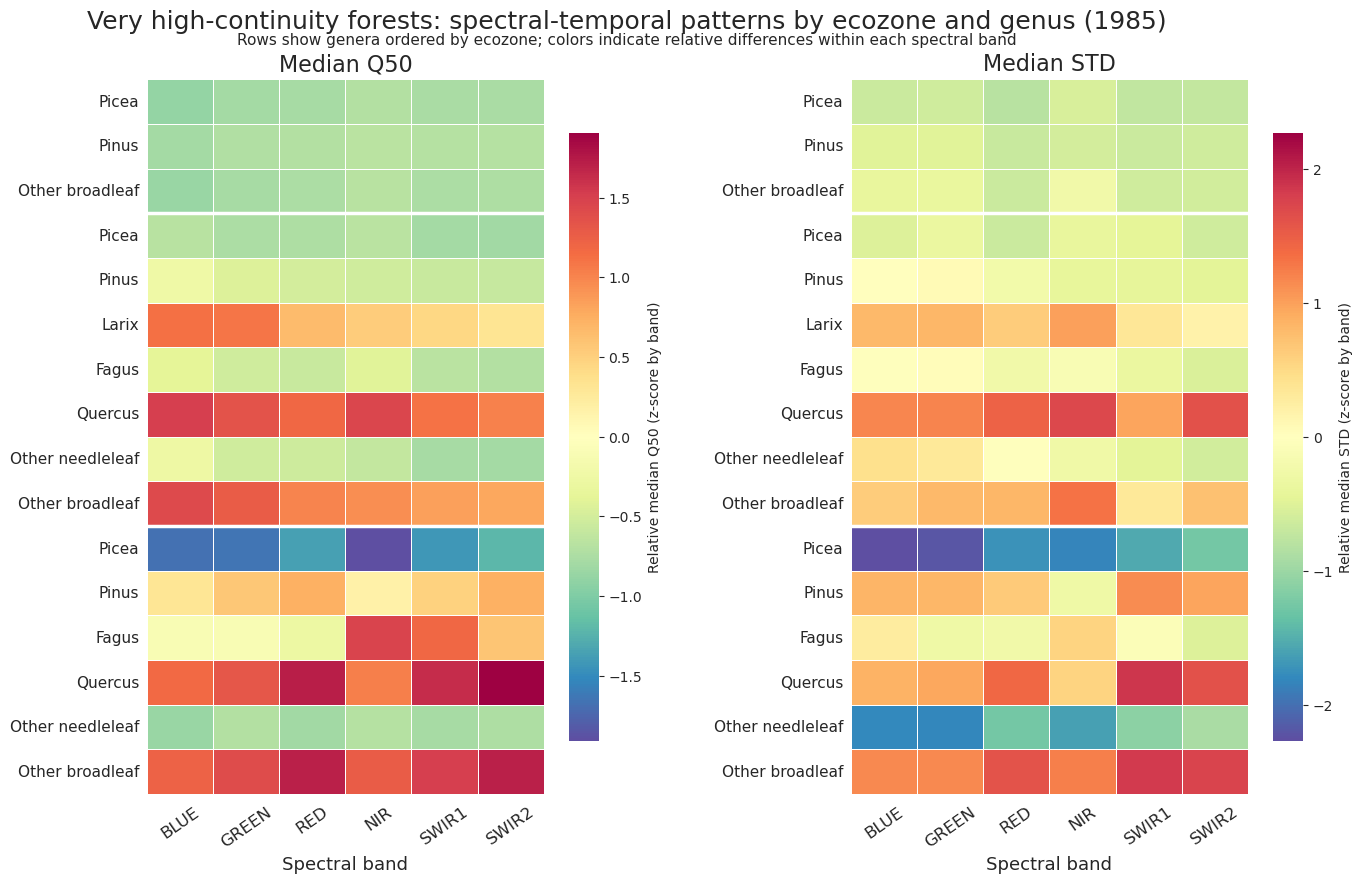

/mnt/eo/EO4Backcasting/_analysis_samples/heatmap_clean_very_high_continuity_ecozone_genus_Q50_STD_1985_standardized_minsamples_50_no_ecozone_labels.png


In [63]:
# ------------------------------------------------------------
# Cleaner heatmap of very high-continuity forests by ecozone and genus
# showing Q50 and STD (or SD) side by side
# - improved row labels
# - no sample counts
# - no Boreal / Temperate / Mediterranean labels on the left
# - optional minimum sample threshold
# ------------------------------------------------------------

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

bands_plot = ["BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2"]
target_prob_class = "very_high_090_100"

# If True, values are z-standardized within each spectral band
standardize = True

# Optional: remove combinations with very few samples
min_samples = 50

# Manual order
genera_order = [
    "Picea",
    "Pinus",
    "Larix",
    "Fagus",
    "Quercus",
    "Other needleleaf",
    "Other broadleaf"
]

ecozone_order = ["Boreal", "Temperate", "Mediterranean"]

# ------------------------------------------------------------
# Detect metric names
# ------------------------------------------------------------

def detect_metric(df, bands, preferred_candidates):
    for cand in preferred_candidates:
        cols = [f"{band}_{cand}" for band in bands]
        if all(col in df.columns for col in cols):
            return cand
    return None

metric_q50 = detect_metric(df_analysis, bands_plot, ["Q50"])
metric_std = detect_metric(df_analysis, bands_plot, ["STD", "SD"])

if metric_q50 is None:
    raise ValueError(
        "Could not find Q50 columns in df_analysis.\n"
        f"Expected columns like: {[f'{b}_Q50' for b in bands_plot]}"
    )

if metric_std is None:
    raise ValueError(
        "Could not find STD/SD columns in df_analysis.\n"
        f"Checked: {[f'{b}_STD' for b in bands_plot]} and {[f'{b}_SD' for b in bands_plot]}"
    )

print("Using metrics:")
print("Q50 metric:", metric_q50)
print("STD metric:", metric_std)

q50_cols = [f"{band}_{metric_q50}" for band in bands_plot]
std_cols = [f"{band}_{metric_std}" for band in bands_plot]

# ------------------------------------------------------------
# Prepare dataframe and ecoregion column
# ------------------------------------------------------------

df_plot = df_analysis.copy()

if "ecoregion" not in df_plot.columns:
    if "ecozone_code" in df_plot.columns:
        ecoregion_lookup = {
            1: "Boreal",
            2: "Temperate",
            3: "Mediterranean"
        }
        df_plot["ecoregion"] = df_plot["ecozone_code"].map(ecoregion_lookup)
    else:
        raise ValueError(
            "Neither 'ecoregion' nor 'ecozone_code' found in df_analysis."
        )

# Keep only genera and ecozones actually present
genera_available = df_plot["genus"].dropna().unique().tolist()
genera_order = [g for g in genera_order if g in genera_available and g != "No trees"]

ecozones_available = df_plot["ecoregion"].dropna().unique().tolist()
ecozone_order = [e for e in ecozone_order if e in ecozones_available]

print("Genera shown:")
print(genera_order)

print("Ecozones shown:")
print(ecozone_order)

# ------------------------------------------------------------
# Filter to very high continuity class
# ------------------------------------------------------------

df_plot = df_plot[
    (df_plot["prob_class"] == target_prob_class) &
    (df_plot["genus"].isin(genera_order)) &
    (df_plot["ecoregion"].isin(ecozone_order))
].copy()

print("Samples used before filtering small groups:", len(df_plot))

# Count samples per ecozone-genus combination
df_counts = (
    df_plot
    .groupby(["ecoregion", "genus"])
    .size()
    .reset_index(name="n_samples")
)

display(df_counts.sort_values(["ecoregion", "genus"]))

# Optional filtering of small groups
if min_samples > 0:
    keep_groups = df_counts.loc[
        df_counts["n_samples"] >= min_samples,
        ["ecoregion", "genus"]
    ].copy()

    df_plot = df_plot.merge(
        keep_groups,
        on=["ecoregion", "genus"],
        how="inner"
    )

    print(f"Samples used after filtering groups with n < {min_samples}:", len(df_plot))

# Recompute counts after filtering
df_counts = (
    df_plot
    .groupby(["ecoregion", "genus"])
    .size()
    .reset_index(name="n_samples")
)

display(df_counts.sort_values(["ecoregion", "genus"]))

# ------------------------------------------------------------
# Aggregate median Q50 and median STD/SD
# ------------------------------------------------------------

agg_dict = {col: "median" for col in q50_cols + std_cols}

df_summary = (
    df_plot
    .groupby(["ecoregion", "genus"], as_index=False)
    .agg(agg_dict)
)

df_summary = df_summary.merge(df_counts, on=["ecoregion", "genus"], how="left")

# ------------------------------------------------------------
# Enforce row order
# ------------------------------------------------------------

row_order = [(eco, gen) for eco in ecozone_order for gen in genera_order]

df_summary["row_key"] = list(zip(df_summary["ecoregion"], df_summary["genus"]))
df_summary = df_summary[df_summary["row_key"].isin(row_order)].copy()

row_order_present = [rk for rk in row_order if rk in df_summary["row_key"].tolist()]

df_summary["row_key"] = pd.Categorical(
    df_summary["row_key"],
    categories=row_order_present,
    ordered=True
)

df_summary = df_summary.sort_values("row_key").copy()

# Use genus only as row label
df_summary["row_label"] = df_summary["genus"].astype(str)

# ------------------------------------------------------------
# Build heatmap matrices
# ------------------------------------------------------------

q50_matrix = df_summary[q50_cols].copy()
q50_matrix.columns = bands_plot
q50_matrix.index = df_summary["row_label"]

std_matrix = df_summary[std_cols].copy()
std_matrix.columns = bands_plot
std_matrix.index = df_summary["row_label"]

# ------------------------------------------------------------
# Optional standardization
# ------------------------------------------------------------

def zscore_columns(df):
    df_z = df.copy().astype(float)

    for col in df_z.columns:
        col_std = df_z[col].std()

        if pd.isna(col_std) or col_std == 0:
            df_z[col] = 0.0
        else:
            df_z[col] = (df_z[col] - df_z[col].mean()) / col_std

    return df_z

if standardize:
    q50_plot = zscore_columns(q50_matrix)
    std_plot = zscore_columns(std_matrix)
    cbar_label_q50 = "Relative median Q50 (z-score by band)"
    cbar_label_std = f"Relative median {metric_std} (z-score by band)"
else:
    q50_plot = q50_matrix.copy()
    std_plot = std_matrix.copy()
    cbar_label_q50 = "Median Q50 STM value"
    cbar_label_std = f"Median {metric_std} STM value"

# ------------------------------------------------------------
# Determine row boundaries between ecozones
# ------------------------------------------------------------

row_meta = df_summary[["ecoregion", "genus", "row_label"]].copy().reset_index(drop=True)

boundary_positions = []

for eco in ecozone_order:
    idx = row_meta.index[row_meta["ecoregion"] == eco].tolist()

    if len(idx) == 0:
        continue

    last = max(idx)

    if last < len(row_meta) - 1:
        boundary_positions.append(last + 1)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

sns.set_style("white")

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, max(8, 0.42 * len(q50_plot) + 2)),
    constrained_layout=False
)

heatmap_kwargs = dict(
    cmap="Spectral_r",   # <- change this if you want another palette
    linewidths=0.4,
    linecolor="white",
    cbar=True,
    yticklabels=True
)

# Standardized heatmaps with symmetric color scale
if standardize:
    vmax_q50 = np.nanmax(np.abs(q50_plot.values))
    vmax_std = np.nanmax(np.abs(std_plot.values))

    vmax_q50 = max(1.0, vmax_q50)
    vmax_std = max(1.0, vmax_std)

    sns.heatmap(
        q50_plot,
        ax=axes[0],
        vmin=-vmax_q50,
        vmax=vmax_q50,
        center=0,
        cbar_kws={"label": cbar_label_q50, "shrink": 0.85},
        **heatmap_kwargs
    )

    sns.heatmap(
        std_plot,
        ax=axes[1],
        vmin=-vmax_std,
        vmax=vmax_std,
        center=0,
        cbar_kws={"label": cbar_label_std, "shrink": 0.85},
        **heatmap_kwargs
    )
else:
    sns.heatmap(
        q50_plot,
        ax=axes[0],
        cbar_kws={"label": cbar_label_q50, "shrink": 0.85},
        **heatmap_kwargs
    )

    sns.heatmap(
        std_plot,
        ax=axes[1],
        cbar_kws={"label": cbar_label_std, "shrink": 0.85},
        **heatmap_kwargs
    )

# ------------------------------------------------------------
# Styling + ecozone separator lines
# ------------------------------------------------------------

for ax in axes:
    for y in boundary_positions:
        ax.hlines(
            y,
            *ax.get_xlim(),
            colors="white",
            linewidth=2.5
        )

    ax.set_xlabel("Spectral band", fontsize=13)
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=12, rotation=35)
    ax.tick_params(axis="y", labelsize=11, rotation=0, pad=2)

# ------------------------------------------------------------
# Titles
# ------------------------------------------------------------

axes[0].set_title(f"Median {metric_q50}", fontsize=16)
axes[1].set_title(f"Median {metric_std}", fontsize=16)

fig.suptitle(
    f"Very high-continuity forests: spectral-temporal patterns by ecozone and genus ({stm_year})",
    fontsize=18,
    y=0.98
)

fig.text(
    0.5, 0.945,
    "Rows show genera ordered by ecozone; colors indicate relative differences within each spectral band",
    ha="center",
    va="center",
    fontsize=11
)

# Slightly smaller left margin now that ecozone labels are removed
fig.subplots_adjust(
    left=0.18,
    right=0.98,
    top=0.90,
    bottom=0.08,
    wspace=0.42
)

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

suffix = "standardized" if standardize else "raw"
suffix_n = f"minsamples_{min_samples}" if min_samples > 0 else "allgroups"

out_plot_fp = os.path.join(
    out_dir,
    f"heatmap_clean_very_high_continuity_ecozone_genus_Q50_{metric_std}_{stm_year}_{suffix}_{suffix_n}_no_ecozone_labels.png"
)

plt.savefig(out_plot_fp, dpi=300, bbox_inches="tight")
plt.show()

print(out_plot_fp)

Using metrics:
Q50 metric: Q50
STD metric: STD
Genera shown:
['Picea', 'Pinus', 'Larix', 'Fagus', 'Quercus', 'Other needleleaf', 'Other broadleaf']
Ecozones shown:
['Boreal', 'Temperate', 'Mediterranean']
Sample counts before filtering:


,ecoregion,genus,prob_class,n_samples
0,Boreal,Other broadleaf,very_high_090_100,4802
1,Boreal,Other broadleaf,very_low_0_025,1565
2,Boreal,Other needleleaf,very_high_090_100,6
3,Boreal,Picea,very_high_090_100,36089
4,Boreal,Picea,very_low_0_025,3389
5,Boreal,Pinus,very_high_090_100,9103
6,Boreal,Pinus,very_low_0_025,7546
7,Mediterranean,Fagus,very_high_090_100,479
8,Mediterranean,Fagus,very_low_0_025,1555
9,Mediterranean,Larix,very_high_090_100,22


Samples after filtering groups with n < 50 in either class:
187436


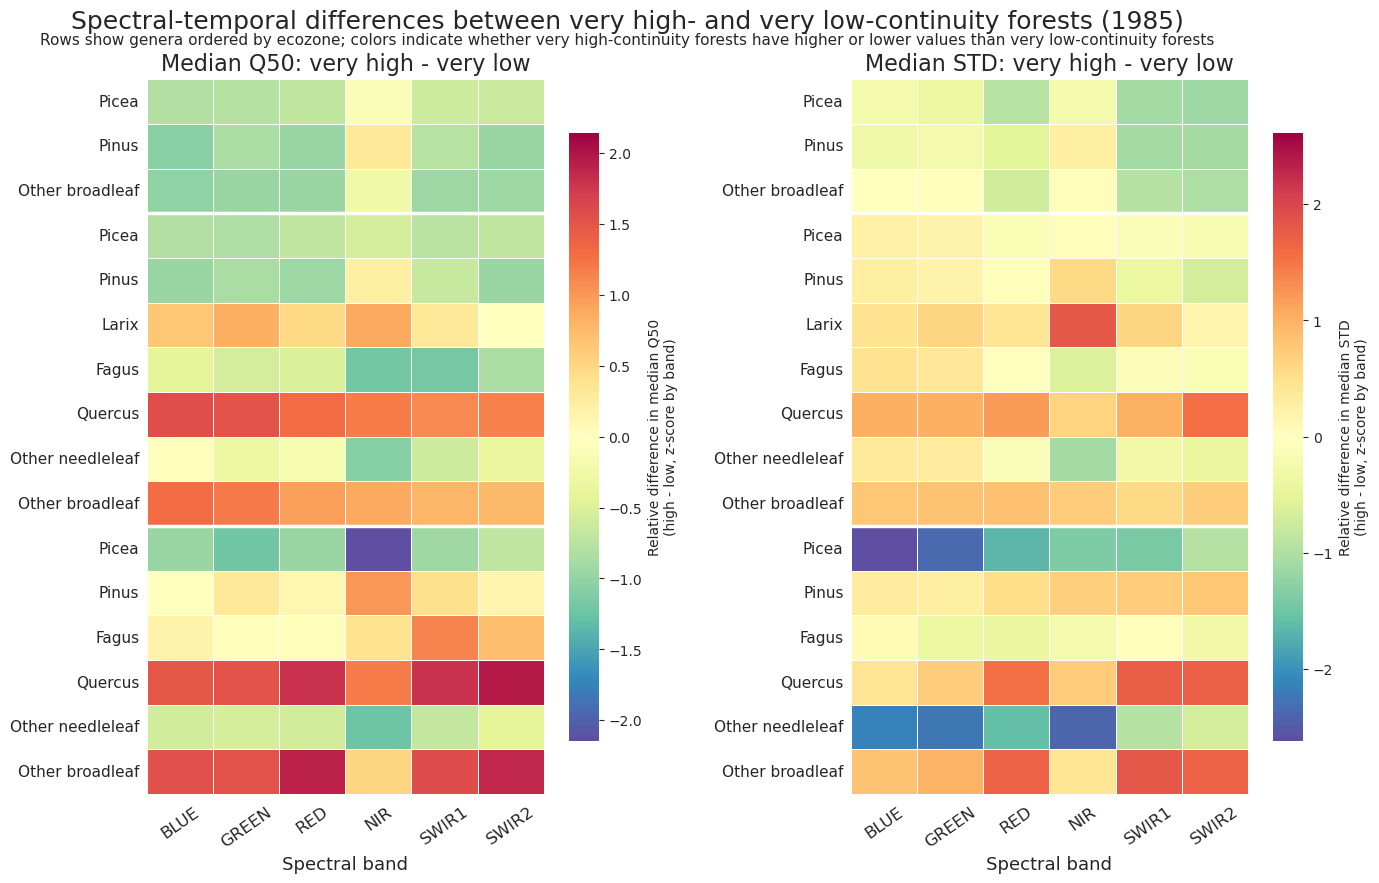

/mnt/eo/EO4Backcasting/_analysis_samples/heatmap_difference_very_high_minus_very_low_Q50_STD_1985_standardized_minsamples_50.png


In [64]:
# ------------------------------------------------------------
# Difference heatmap: very high vs very low continuity forests
# Q50 and STD/SD
#
# Values shown:
#   median(very high) - median(very low)
#
# Rows:
#   Ecozone | Genus combinations
#
# Columns:
#   Spectral bands
# ------------------------------------------------------------

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

bands_plot = ["BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2"]

high_prob_class = "very_high_090_100"
low_prob_class = "very_low_0_025"

# If True, differences are z-standardized per band across rows.
# This makes the heatmap easier to compare visually across bands.
standardize_difference = True

# Minimum sample size per ecozone-genus-probability class.
# A row is only kept if both very high and very low have at least this many samples.
min_samples = 50

# Manual order
genera_order = [
    "Picea",
    "Pinus",
    "Larix",
    "Fagus",
    "Quercus",
    "Other needleleaf",
    "Other broadleaf"
]

ecozone_order = ["Boreal", "Temperate", "Mediterranean"]

# ------------------------------------------------------------
# Detect metric names
# ------------------------------------------------------------

def detect_metric(df, bands, preferred_candidates):
    """
    Detect which metric name exists in the dataframe.
    For example: Q50, STD, SD.
    """
    for cand in preferred_candidates:
        cols = [f"{band}_{cand}" for band in bands]
        if all(col in df.columns for col in cols):
            return cand
    return None


metric_q50 = detect_metric(df_analysis, bands_plot, ["Q50"])
metric_std = detect_metric(df_analysis, bands_plot, ["STD", "SD"])

if metric_q50 is None:
    raise ValueError(
        "Could not find Q50 columns in df_analysis.\n"
        f"Expected columns like: {[f'{b}_Q50' for b in bands_plot]}"
    )

if metric_std is None:
    raise ValueError(
        "Could not find STD/SD columns in df_analysis.\n"
        f"Checked: {[f'{b}_STD' for b in bands_plot]} and {[f'{b}_SD' for b in bands_plot]}"
    )

print("Using metrics:")
print("Q50 metric:", metric_q50)
print("STD metric:", metric_std)

q50_cols = [f"{band}_{metric_q50}" for band in bands_plot]
std_cols = [f"{band}_{metric_std}" for band in bands_plot]
metric_cols = q50_cols + std_cols

# ------------------------------------------------------------
# Prepare dataframe and ecoregion column
# ------------------------------------------------------------

df_plot = df_analysis.copy()

if "ecoregion" not in df_plot.columns:
    if "ecozone_code" in df_plot.columns:
        ecoregion_lookup = {
            1: "Boreal",
            2: "Temperate",
            3: "Mediterranean"
        }
        df_plot["ecoregion"] = df_plot["ecozone_code"].map(ecoregion_lookup)
    else:
        raise ValueError(
            "Neither 'ecoregion' nor 'ecozone_code' found in df_analysis."
        )

# Keep only available genera and ecozones
genera_available = df_plot["genus"].dropna().unique().tolist()
genera_order = [g for g in genera_order if g in genera_available and g != "No trees"]

ecozones_available = df_plot["ecoregion"].dropna().unique().tolist()
ecozone_order = [e for e in ecozone_order if e in ecozones_available]

print("Genera shown:")
print(genera_order)

print("Ecozones shown:")
print(ecozone_order)

# ------------------------------------------------------------
# Filter to very low and very high probability classes
# ------------------------------------------------------------

df_plot = df_plot[
    df_plot["prob_class"].isin([low_prob_class, high_prob_class]) &
    df_plot["genus"].isin(genera_order) &
    df_plot["ecoregion"].isin(ecozone_order)
].copy()

# Remove invalid values
df_plot = df_plot.replace([np.inf, -np.inf], np.nan)

# ------------------------------------------------------------
# Count samples per ecozone × genus × probability class
# ------------------------------------------------------------

df_counts = (
    df_plot
    .groupby(["ecoregion", "genus", "prob_class"])
    .size()
    .reset_index(name="n_samples")
)

print("Sample counts before filtering:")
display(
    df_counts
    .sort_values(["ecoregion", "genus", "prob_class"])
)

# Keep only ecozone-genus combinations where both probability classes
# have enough samples
count_wide = (
    df_counts
    .pivot_table(
        index=["ecoregion", "genus"],
        columns="prob_class",
        values="n_samples",
        fill_value=0
    )
    .reset_index()
)

for cls in [low_prob_class, high_prob_class]:
    if cls not in count_wide.columns:
        count_wide[cls] = 0

keep_groups = count_wide[
    (count_wide[low_prob_class] >= min_samples) &
    (count_wide[high_prob_class] >= min_samples)
][["ecoregion", "genus"]].copy()

df_plot = df_plot.merge(
    keep_groups,
    on=["ecoregion", "genus"],
    how="inner"
)

print(f"Samples after filtering groups with n < {min_samples} in either class:")
print(len(df_plot))

# ------------------------------------------------------------
# Aggregate median values per ecozone × genus × probability class
# ------------------------------------------------------------

agg_dict = {col: "median" for col in metric_cols}

df_medians = (
    df_plot
    .groupby(["ecoregion", "genus", "prob_class"], as_index=False)
    .agg(agg_dict)
)

# ------------------------------------------------------------
# Convert to wide format and calculate differences
# ------------------------------------------------------------

df_high = df_medians[df_medians["prob_class"] == high_prob_class].copy()
df_low = df_medians[df_medians["prob_class"] == low_prob_class].copy()

df_diff = df_high.merge(
    df_low,
    on=["ecoregion", "genus"],
    suffixes=("_high", "_low"),
    how="inner"
)

# Calculate high - low for each metric column
for col in metric_cols:
    df_diff[f"{col}_diff"] = df_diff[f"{col}_high"] - df_diff[f"{col}_low"]

# ------------------------------------------------------------
# Enforce row order
# ------------------------------------------------------------

row_order = [(eco, gen) for eco in ecozone_order for gen in genera_order]

df_diff["row_key"] = list(zip(df_diff["ecoregion"], df_diff["genus"]))
df_diff = df_diff[df_diff["row_key"].isin(row_order)].copy()

row_order_present = [rk for rk in row_order if rk in df_diff["row_key"].tolist()]

df_diff["row_key"] = pd.Categorical(
    df_diff["row_key"],
    categories=row_order_present,
    ordered=True
)

df_diff = df_diff.sort_values("row_key").copy()

# Use genus only as row label, grouped by ecozone through separator lines
df_diff["row_label"] = df_diff["genus"].astype(str)

# ------------------------------------------------------------
# Build heatmap matrices
# ------------------------------------------------------------

q50_diff_cols = [f"{col}_diff" for col in q50_cols]
std_diff_cols = [f"{col}_diff" for col in std_cols]

q50_matrix = df_diff[q50_diff_cols].copy()
q50_matrix.columns = bands_plot
q50_matrix.index = df_diff["row_label"]

std_matrix = df_diff[std_diff_cols].copy()
std_matrix.columns = bands_plot
std_matrix.index = df_diff["row_label"]

# ------------------------------------------------------------
# Optional standardization of differences
# ------------------------------------------------------------

def zscore_columns(df):
    """
    Z-standardize each column separately.
    """
    df_z = df.copy().astype(float)

    for col in df_z.columns:
        col_std = df_z[col].std()

        if pd.isna(col_std) or col_std == 0:
            df_z[col] = 0.0
        else:
            df_z[col] = (df_z[col] - df_z[col].mean()) / col_std

    return df_z


if standardize_difference:
    q50_plot = zscore_columns(q50_matrix)
    std_plot = zscore_columns(std_matrix)

    cbar_label_q50 = "Relative difference in median Q50\n(high - low, z-score by band)"
    cbar_label_std = f"Relative difference in median {metric_std}\n(high - low, z-score by band)"
else:
    q50_plot = q50_matrix.copy()
    std_plot = std_matrix.copy()

    cbar_label_q50 = "Difference in median Q50\n(high - low)"
    cbar_label_std = f"Difference in median {metric_std}\n(high - low)"

# ------------------------------------------------------------
# Determine row boundaries between ecozones
# ------------------------------------------------------------

row_meta = df_diff[["ecoregion", "genus", "row_label"]].copy().reset_index(drop=True)

boundary_positions = []

for eco in ecozone_order:
    idx = row_meta.index[row_meta["ecoregion"] == eco].tolist()

    if len(idx) == 0:
        continue

    last = max(idx)

    if last < len(row_meta) - 1:
        boundary_positions.append(last + 1)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

sns.set_style("white")

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, max(8, 0.42 * len(q50_plot) + 2)),
    constrained_layout=False
)

heatmap_kwargs = dict(
    cmap="Spectral_r",
    linewidths=0.4,
    linecolor="white",
    cbar=True,
    yticklabels=True
)

# Symmetric color limits
if standardize_difference:
    vmax_q50 = np.nanmax(np.abs(q50_plot.values))
    vmax_std = np.nanmax(np.abs(std_plot.values))

    vmax_q50 = max(1.0, vmax_q50)
    vmax_std = max(1.0, vmax_std)
else:
    vmax_q50 = np.nanmax(np.abs(q50_plot.values))
    vmax_std = np.nanmax(np.abs(std_plot.values))

sns.heatmap(
    q50_plot,
    ax=axes[0],
    vmin=-vmax_q50,
    vmax=vmax_q50,
    center=0,
    cbar_kws={"label": cbar_label_q50, "shrink": 0.85},
    **heatmap_kwargs
)

sns.heatmap(
    std_plot,
    ax=axes[1],
    vmin=-vmax_std,
    vmax=vmax_std,
    center=0,
    cbar_kws={"label": cbar_label_std, "shrink": 0.85},
    **heatmap_kwargs
)

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

for ax in axes:
    # separator lines between ecozones
    for y in boundary_positions:
        ax.hlines(
            y,
            *ax.get_xlim(),
            colors="white",
            linewidth=2.5
        )

    ax.set_xlabel("Spectral band", fontsize=13)
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=12, rotation=35)
    ax.tick_params(axis="y", labelsize=11, rotation=0, pad=2)

axes[0].set_title(f"Median {metric_q50}: very high - very low", fontsize=16)
axes[1].set_title(f"Median {metric_std}: very high - very low", fontsize=16)

fig.suptitle(
    f"Spectral-temporal differences between very high- and very low-continuity forests ({stm_year})",
    fontsize=18,
    y=0.98
)

fig.text(
    0.5,
    0.945,
    "Rows show genera ordered by ecozone; colors indicate whether very high-continuity forests have higher or lower values than very low-continuity forests",
    ha="center",
    va="center",
    fontsize=11
)

fig.subplots_adjust(
    left=0.18,
    right=0.98,
    top=0.90,
    bottom=0.08,
    wspace=0.42
)

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

suffix = "standardized" if standardize_difference else "raw"
suffix_n = f"minsamples_{min_samples}" if min_samples > 0 else "allgroups"

out_plot_fp = os.path.join(
    out_dir,
    f"heatmap_difference_very_high_minus_very_low_Q50_{metric_std}_{stm_year}_{suffix}_{suffix_n}.png"
)

plt.savefig(out_plot_fp, dpi=300, bbox_inches="tight")
plt.show()

print(out_plot_fp)